# 3. Circumplex Model Mapping
In this part we extract each emotional category to set it as valence and arousal score.

In [1]:
from circumplex_mapping_test import CircumplexMapping
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import importlib

In [2]:
import circumplex_mapping_test
importlib.reload(circumplex_mapping_test)

<module 'circumplex_mapping_test' from '/Users/chiahao/Documents/Research A/LLM for mental health detection/circumplex_mapping_test.py'>

In [3]:
with open("vad_cols.txt") as f:
    vad_cols = [l.strip() for l in f if l.strip()]

empath_df = pd.read_csv("./data/empath_data.csv")
empath_weekly = pd.read_csv("./data/empath_weekly.csv")

vad_cols = [c for c in vad_cols if c in empath_df.columns]
meta = ['user_id','post_id', 'comment_id','timestamp','date','week','is_post','category','thread_owner_id','clean_text']

df_vad = empath_df[meta + vad_cols].copy()

nrc_vad_path = "./NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt"
circ = CircumplexMapping(vad_path=nrc_vad_path)

mapped = circ.map_dataframe(df_vad, prefix='empath_')


Loaded NRC-VAD: 54800 terms
Empath circumplex mapping created with 28 terms
  NRC-VAD based: 26
  Manual fallbacks: 2


In [4]:
mapped.shape

(42384, 30)

In [5]:
mapped.head()

,user_id,post_id,comment_id,timestamp,date,week,is_post,category,thread_owner_id,clean_text,...,empath_fear,empath_trust,empath_hate,empath_therapy,empath_sleep,empath_anger,empath_shame,empath_optimism,valence,arousal
0,5925,4921,0,2019-01-06,2019-01-06,2018-12-31,True,PTSD and trauma,5925,hello first post ive reading forum background ...,...,0.032258,0.008065,0.016129,0.032258,0.000000,0.032258,0.040323,0.024194,-0.538564,-0.413846
1,1006,4921,1,2019-01-06,2019-01-06,2018-12-31,False,PTSD and trauma,5925,dear catladyintraining welcome imagine number ...,...,0.016575,0.022099,0.033149,0.044199,0.000000,0.005525,0.016575,0.049724,-0.334078,-0.448416
2,1442,4921,2,2019-01-07,2019-01-07,2019-01-07,False,PTSD and trauma,5925,dear catladyintraining first want welcome foru...,...,0.010526,0.031579,0.015789,0.005263,0.000000,0.015789,0.015789,0.047368,-0.349333,-0.311394
3,2863,4921,3,2019-01-07,2019-01-07,2019-01-07,False,PTSD and trauma,5925,catladyintraining welcome forum croix mary giv...,...,0.062500,0.031250,0.062500,0.007812,0.000000,0.062500,0.062500,0.039062,-0.631216,-0.220784
4,6342,5307,0,2019-01-08,2019-01-08,2019-01-07,True,PTSD and trauma,6342,last pregnancy deal series traumatic event rea...,...,0.000000,0.024390,0.014634,0.004878,0.034146,0.000000,0.024390,0.000000,-0.469574,-0.387344


In [ ]:
# raw
mapped = mapped.dropna(subset=['valence','arousal']).copy()

mapped['radius'] = np.sqrt(mapped['valence']**2 + mapped['arousal']**2)
mapped['angle_rad'] = np.arctan2(mapped['arousal'], mapped['valence'])
mapped['angle_deg'] = np.degrees(mapped['angle_rad'])

def quadrant(row):
    if   row['valence'] >= 0 and row['arousal'] >= 0: return 'High Positive (Excited)'
    elif row['valence'] >= 0 and row['arousal'] <  0: return 'Low Positive (Content)'
    elif row['valence'] <  0  and row['arousal'] >= 0: return 'High Negative (Distressed)'
    else:                                               return 'Low Negative (Sad)'

mapped['quadrant'] = mapped.apply(quadrant, axis=1)

# z-score
for c in ['valence','arousal']:
    mu = mapped[c].mean()
    sd = mapped[c].std(ddof=0) + 1e-8
    mapped[c + '_z'] = (mapped[c] - mu) / sd
    
mapped['radius_z'] = np.sqrt(mapped['valence_z']**2 + mapped['arousal_z']**2)
mapped['angle_rad_z'] = np.arctan2(mapped['arousal_z'], mapped['valence_z'])
mapped['angle_deg_z'] = np.degrees(mapped['angle_rad_z'])

def quadrant_z(row):
    if   row['valence_z'] >= 0 and row['arousal_z'] >= 0: return 'Q1 (+V,+A)'
    elif row['valence_z'] <  0 and row['arousal_z'] >= 0: return 'Q2 (-V,+A)'
    elif row['valence_z'] <  0 and row['arousal_z'] <  0: return 'Q3 (-V,-A)'
    else:                                                  return 'Q4 (+V,-A)'

mapped['quadrant_z'] = mapped.apply(quadrant_z, axis=1)


In [7]:
def compute_category_vectors(
    df: pd.DataFrame,
    prefix: str = 'empath_',
    use_z: bool = True,
    min_posts: int = 100,
    categories: list[str] | None = None,
    ) -> pd.DataFrame:
    V = 'valence_z' if use_z else 'valence'
    A = 'arousal_z' if use_z else 'arousal'
    if categories is None:
        cols = [c for c in df.columns if c.startswith(prefix)]
        cats = [c[len(prefix):] for c in cols]
    else:
        cols = [f'{prefix}{c}' for c in categories if f'{prefix}{c}' in df.columns]
        cats = [c[len(prefix):] for c in cols]

    rows = []
    for col, cat in zip(cols, cats):
        mask = df[col] > 0
        n = int(mask.sum())
        if n < min_posts:
            continue
        sub = df.loc[mask, [V, A, col]]
        # average V/A for posts where the category appears
        vx, vy = sub[V].mean(), sub[A].mean()
        mean_w = sub[col].mean()
        rows.append((cat, vx, vy, n, mean_w))

    out = pd.DataFrame(rows, columns=['cat','vx','vy','n_posts','mean_w'])
    out['angle'] = np.degrees(np.arctan2(out['vy'], out['vx']))
    return out.sort_values('angle').drop(columns='angle').reset_index(drop=True)

cat_vectors_z = compute_category_vectors(
    mapped,
    prefix='empath_',
    use_z=True,
    min_posts=100,           
    categories=None         
)
cat_vectors_z

,cat,vx,vy,n_posts,mean_w
0,sleep,-0.171330,-0.016597,10937,0.021256
1,health,-0.092513,-0.089697,26364,0.047443
2,help,-0.064022,-0.121621,27847,0.035161
3,therapy,-0.067744,-0.194745,20425,0.030897
4,trust,0.002971,-0.030807,23758,0.025478
5,optimism,0.039347,-0.010927,30328,0.036911
6,love,-0.068848,0.188510,27612,0.032447
7,contentment,-0.202284,0.269565,26350,0.032652
8,violence,-0.262893,0.281878,29154,0.034025
9,anxiety,-0.264630,0.249788,31988,0.059390


In [ ]:
# Whitened
Z = mapped[['valence_z','arousal_z']].to_numpy()

# Compute whitening matrix on the z-scored space
Sigma = np.cov(Z, rowvar=False)          
w, V = np.linalg.eigh(Sigma)             
W = V @ np.diag(1/np.sqrt(w)) @ V.T    

# Apply whitening
Zw = Z @ W.T
mapped['valence_w'] = Zw[:,0]
mapped['arousal_w'] = Zw[:,1]

# Angles/radii in whitened space
mapped['angle_w']  = np.arctan2(mapped['arousal_w'], mapped['valence_w'])
mapped['radius_w'] = np.hypot(mapped['valence_w'], mapped['arousal_w'])

We mapped Empath categories to valence/arousal using NRC-VAD, then z-score and whiten to remove scaling effects

## 3.1. Validation

### 3.1.1. Coverage Check

In [ ]:
print("\n Top Empath Categories and Their Mappings ")
cols = [col for col in mapped.columns if col.startswith('empath_')]
top_empath_features = mapped[cols].mean().sort_values(ascending=False).head(20)

for feature in top_empath_features.index:
    valence, arousal = circ._get_coords(feature)
    clean_name = feature.replace('empath_', '').replace('_', ' ').lower()
    
    if hasattr(circ, 'empath_circumplex_map'):
        mapping_source = "Expert" if clean_name in circ.empath_circumplex_map else "Fallback"
    else:
        mapping_source = "Unknown"

    avg_score = mapped[feature].mean()
    print(f"{feature:30} → V:{valence:6.3f}, A:{arousal:6.3f} ({mapping_source}) [Avg: {avg_score:.4f}]")


 Top Empath Categories and Their Mappings 
empath_anxiety                 → V:-1.000, A: 0.460 (Expert) [Avg: 0.0448]
empath_health                  → V: 0.740, A:-1.000 (Fallback) [Avg: 0.0295]
empath_pain                    → V:-1.000, A: 0.060 (Fallback) [Avg: 0.0290]
empath_shame                   → V:-1.000, A:-0.320 (Expert) [Avg: 0.0271]
empath_sadness                 → V:-1.000, A:-1.000 (Expert) [Avg: 0.0270]
empath_optimism                → V: 0.796, A:-0.740 (Expert) [Avg: 0.0264]
empath_depression              → V:-1.000, A:-0.920 (Expert) [Avg: 0.0247]
empath_violence                → V:-1.000, A: 0.732 (Fallback) [Avg: 0.0234]
empath_help                    → V:-0.308, A:-1.000 (Fallback) [Avg: 0.0231]
empath_suffering               → V:-1.000, A:-0.124 (Fallback) [Avg: 0.0218]
empath_love                    → V: 0.992, A:-0.332 (Expert) [Avg: 0.0211]
empath_contentment             → V: 0.500, A:-0.560 (Expert) [Avg: 0.0203]
empath_fear                    → V:-1.000, A: 

### 3.1.2. Distribution

In [ ]:
print("Quadrant Distribution")
# raw
print(mapped[['valence','arousal']].describe().round(3))

quadrant_counts = mapped['quadrant'].value_counts()
for quadrant, count in quadrant_counts.items():
    percentage = count / len(mapped) * 100
    print(f"  {quadrant}: {count} ({percentage:.1f}%)")


print(f"\nNaN Valence: {mapped['valence'].isna().sum()}, Arousal: {mapped['arousal'].isna().sum()}")
# z-score
print(mapped[['valence_z','arousal_z']].describe().round(3))

quadrant_counts_z = mapped['quadrant_z'].value_counts()
for quadrant, count in quadrant_counts_z.items():
    percentage = count / len(mapped) * 100
    print(f"  {quadrant}: {count} ({percentage:.1f}%)")

print(f"\nNaN Valence: {mapped['valence_z'].isna().sum()}, Arousal: {mapped['arousal_z'].isna().sum()}")

Quadrant Distribution
         valence    arousal
count  42384.000  42384.000
mean      -0.375     -0.384
std        0.307      0.253
min       -1.000     -1.000
25%       -0.562     -0.517
50%       -0.432     -0.345
75%       -0.250     -0.219
max        0.992      0.732
  Low Negative (Sad): 36333 (85.7%)
  Low Positive (Content): 3670 (8.7%)
  High Positive (Excited): 1391 (3.3%)
  High Negative (Distressed): 990 (2.3%)

NaN Valence: 0, Arousal: 0
       valence_z  arousal_z
count  42384.000  42384.000
mean      -0.000      0.000
std        1.000      1.000
min       -2.037     -2.431
25%       -0.608     -0.525
50%       -0.185      0.152
75%        0.409      0.653
max        4.458      4.403
  Q2 (-V,+A): 18919 (44.6%)
  Q4 (+V,-A): 11718 (27.6%)
  Q3 (-V,-A): 6492 (15.3%)
  Q1 (+V,+A): 5255 (12.4%)

NaN Valence: 0, Arousal: 0


We will use raw quadrants for prevalence reporting and cross-group comparisons; use z quadrants for clustering, PCA, and tracking relative shifts over time.

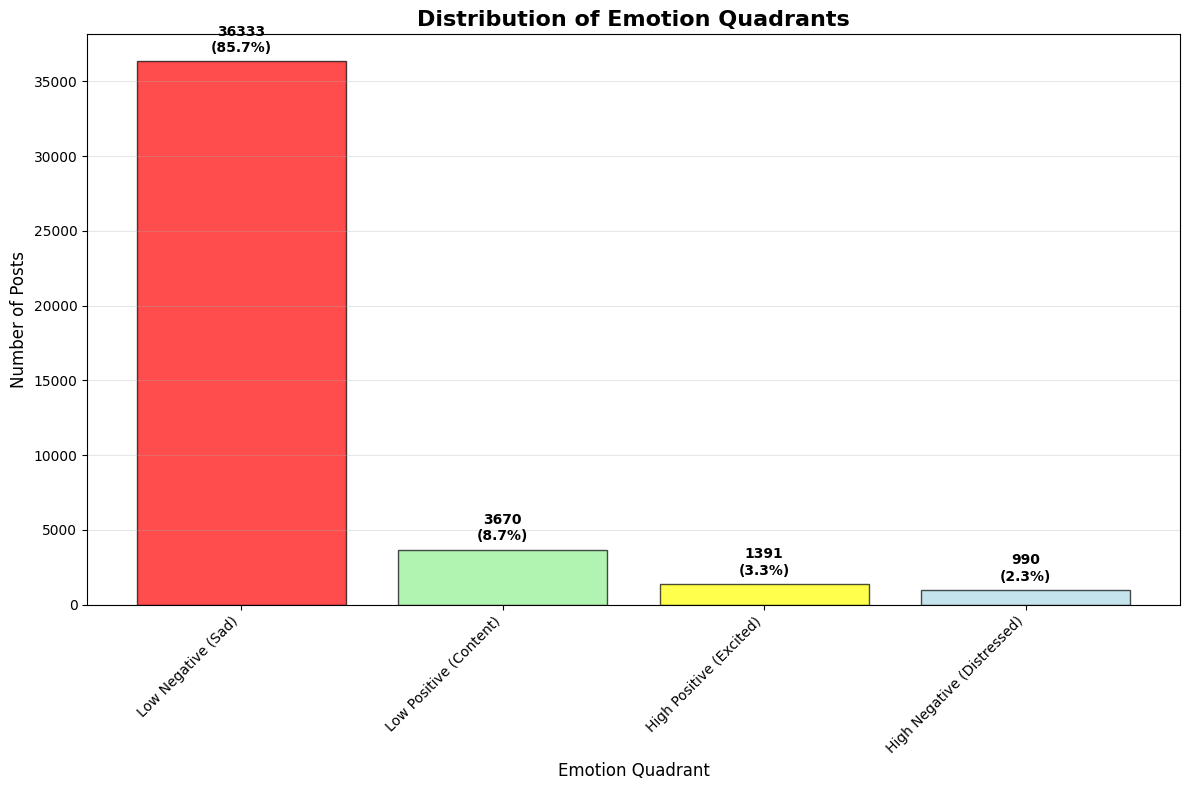

In [11]:
plt.figure(figsize=(12, 8))

colors = ['red', 'lightgreen', 'yellow', 'lightblue']
bars = plt.bar(range(len(quadrant_counts)), quadrant_counts.values, 
               color=colors[:len(quadrant_counts)], alpha=0.7, edgecolor='black')

plt.title('Distribution of Emotion Quadrants', fontsize=16, fontweight='bold')
plt.xlabel('Emotion Quadrant', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(range(len(quadrant_counts)), quadrant_counts.index, rotation=45, ha='right')

# labels
for bar, count in zip(bars, quadrant_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(mapped)*0.01,
            f'{count}\n({count/len(mapped)*100:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [12]:
for forum in mapped['category'].unique():
    forum_data = mapped[mapped['category'] == forum]
    avg_val = forum_data['valence'].mean()
    avg_aro = forum_data['arousal'].mean()
    
    # Get quadrant distribution for this forum
    forum_quadrants = forum_data['quadrant'].value_counts()
    dominant_quadrant = forum_quadrants.index[0]
    
    print(f" {forum}:")
    print(f" Valence={avg_val:.3f}, Arousal={avg_aro:.3f}")
    print(f" Highest quadrant: {dominant_quadrant} ({forum_quadrants.iloc[0]/len(forum_data)*100:.1f}%)")

 PTSD and trauma:
 Valence=-0.380, Arousal=-0.383
 Highest quadrant: Low Negative (Sad) (86.2%)
 Anxiety:
 Valence=-0.384, Arousal=-0.359
 Highest quadrant: Low Negative (Sad) (85.2%)
 Depression:
 Valence=-0.356, Arousal=-0.404
 Highest quadrant: Low Negative (Sad) (85.4%)
 Suicidal thoughts and self-harm:
 Valence=-0.383, Arousal=-0.389
 Highest quadrant: Low Negative (Sad) (86.4%)


Valence and Arousal by Mental Health Category
                                valence               arousal              
                                   mean    std  count    mean    std  count
category                                                                   
Anxiety                          -0.384  0.307  11606  -0.359  0.260  11606
Depression                       -0.356  0.308  11839  -0.404  0.252  11839
PTSD and trauma                  -0.380  0.306   9198  -0.383  0.250   9198
Suicidal thoughts and self-harm  -0.383  0.305   9741  -0.389  0.248   9741


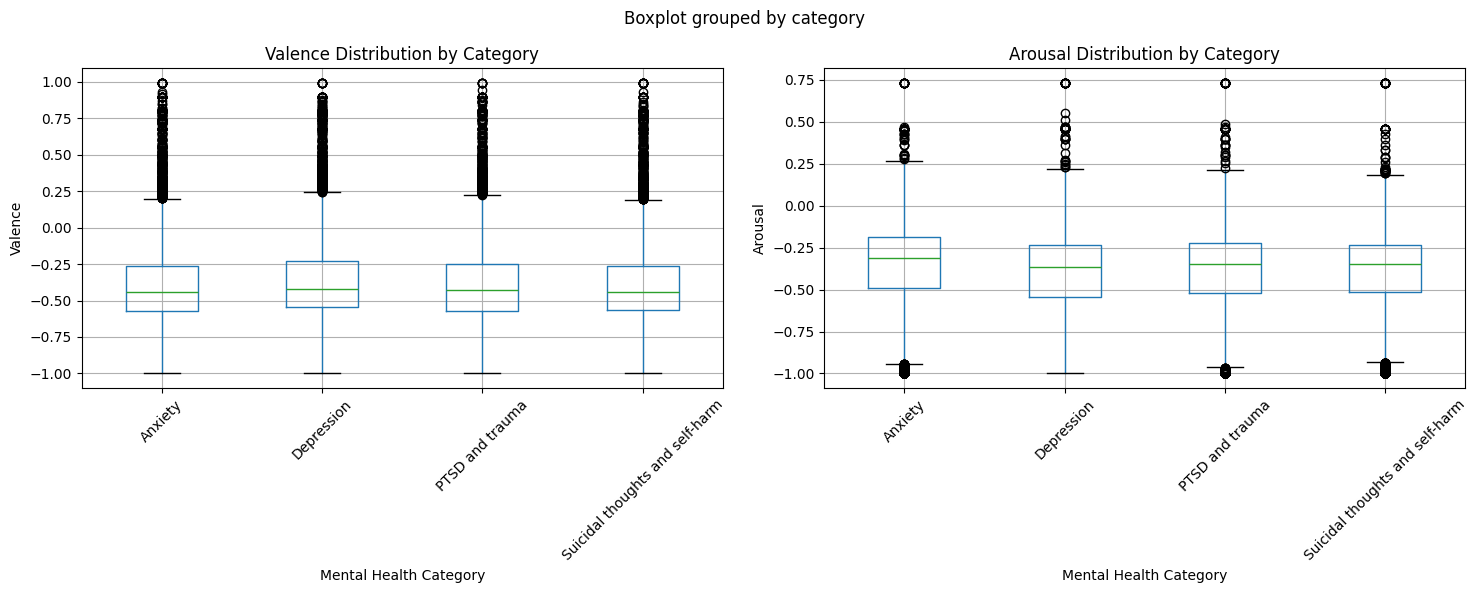

In [13]:
# Analyze valence and arousal by category
category_analysis = mapped.groupby('category')[['valence', 'arousal']].agg(['mean', 'std', 'count'])
print("Valence and Arousal by Mental Health Category")
print(category_analysis.round(3))

# Visualize by category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for valence by category
mapped.boxplot(column='valence', by='category', ax=ax1)
ax1.set_title('Valence Distribution by Category')
ax1.set_xlabel('Mental Health Category')
ax1.set_ylabel('Valence')
ax1.tick_params(axis='x', rotation=45)

# Box plot for arousal by category
mapped.boxplot(column='arousal', by='category', ax=ax2)
ax2.set_title('Arousal Distribution by Category')
ax2.set_xlabel('Mental Health Category')
ax2.set_ylabel('Arousal')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

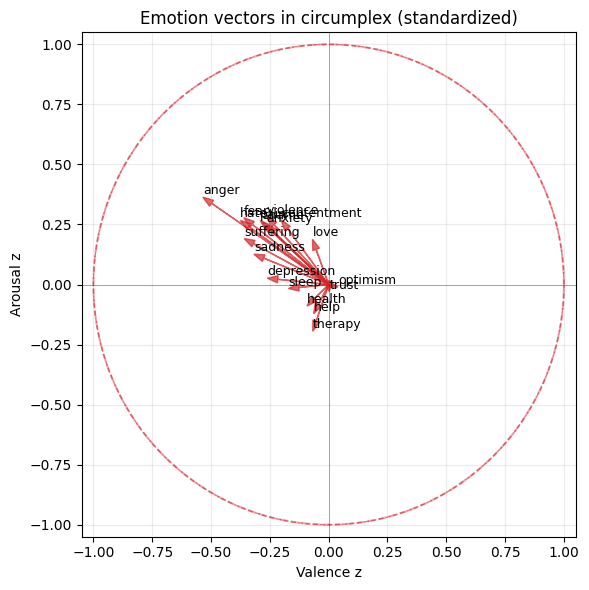

In [ ]:
def _unit_circle(ax, r=1.0, **kw):
    th = np.linspace(0, 2*np.pi, 512)
    ax.plot(r*np.cos(th), r*np.sin(th), **kw)

def plot_emotion_vectors(
    cat_df: pd.DataFrame,
    use_z: bool = True,
    annotate: bool = True,
    title: str | None = None,
    savepath: str | None = None
    ):
    """
    Quick helper to plot category vectors
    """
    Vlab = 'Valence z' if use_z else 'Valence'
    Alab = 'Arousal z' if use_z else 'Arousal'
    ttl  = title or f'Emotion vectors in circumplex ({Vlab} vs {Alab})'

    fig, ax = plt.subplots(figsize=(6, 6))
    # arrows
    for _, r in cat_df.iterrows():
        ax.arrow(0, 0, r.vx, r.vy, length_includes_head=True, head_width=0.03 if use_z else 0.05, fc='tab:red', ec='tab:red', alpha=0.7)
        if annotate:
            ax.text(r.vx, r.vy, r['cat'], fontsize=9, ha='left', va='bottom')
    _unit_circle(ax, 1.0, color='crimson', ls='--', lw=1, alpha=.6)
    # reference circle
    R = 1.0 if use_z else 1.0
    th = np.linspace(0, 2*np.pi, 360)
    ax.plot(R*np.cos(th), R*np.sin(th), ls='--', color='tab:red', alpha=0.4)

    # axes
    ax.axhline(0, color='k', lw=0.7, alpha=0.3)
    ax.axvline(0, color='k', lw=0.7, alpha=0.3)

    # limits: z naturally around [-1,1]; raw can be [-1,1] for NRC
    lim = 1.05 if use_z else 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(Vlab)
    ax.set_ylabel(Alab)
    ax.set_title(ttl)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    
plot_emotion_vectors(
    cat_vectors_z,
    use_z=True,
    annotate=True,
    title='Emotion vectors in circumplex (standardized)'
)

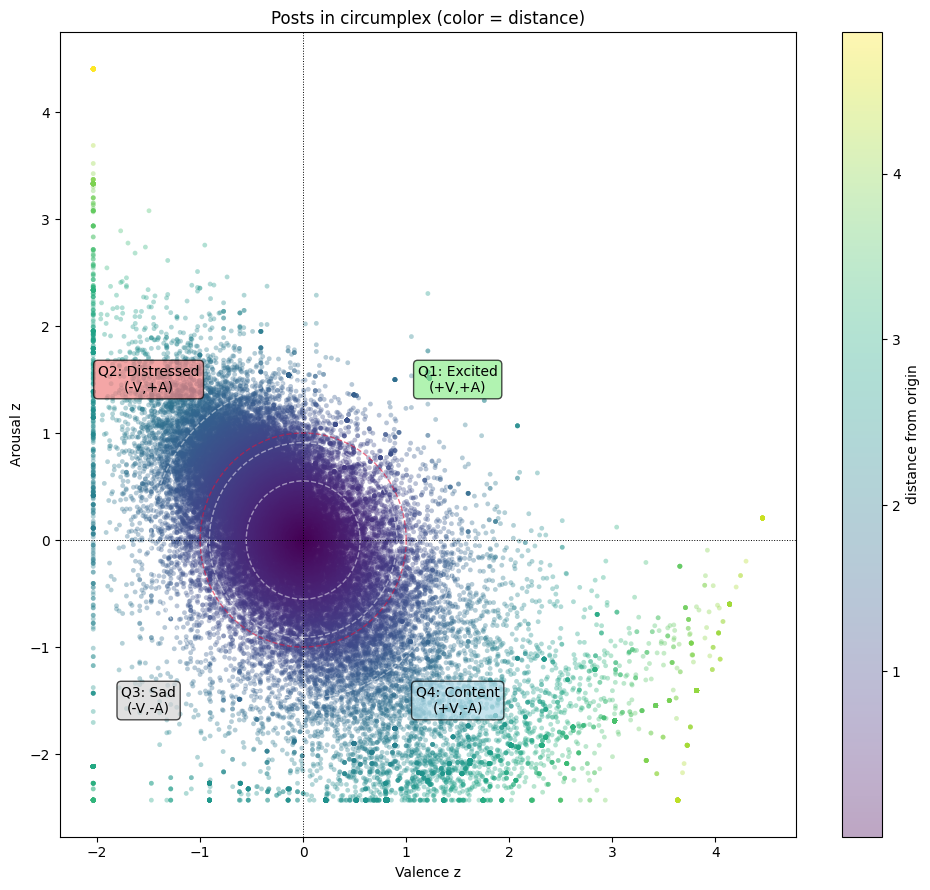

In [15]:
def plot_circular_scatter(mapped_df, sample_alpha=0.35):
    """Scatter of posts in circumplex; color = distance (radius)."""
    R = np.sqrt(mapped_df['valence_z']**2 + mapped_df['arousal_z']**2)
    
    fig, ax = plt.subplots(figsize=(10,9))
    
    sc = ax.scatter(mapped_df['valence_z'], mapped_df['arousal_z'], 
                   c=R, s=12, alpha=sample_alpha, cmap='viridis', 
                   edgecolors='none')
    # Add quadrant labels to help interpretation
    ax.text(-1.5, 1.5, 'Q2: Distressed\n(-V,+A)', ha='center', va='center', 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))
    ax.text(1.5, 1.5, 'Q1: Excited\n(+V,+A)', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
    ax.text(-1.5, -1.5, 'Q3: Sad\n(-V,-A)', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    ax.text(1.5, -1.5, 'Q4: Content\n(+V,-A)', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    # quartile rings
    for q in [0.25, 0.5, 0.75]:
        r = np.quantile(R, q)
        circle = plt.Circle((0,0), r, fill=False, color='white', 
                           alpha=0.5, linewidth=1, linestyle='--')
        ax.add_patch(circle)
    
    _unit_circle(ax, 1.0, color='crimson', ls='--', lw=1, alpha=0.6)
    ax.axhline(0, color='k', lw=.7, ls=':')
    ax.axvline(0, color='k', lw=.7, ls=':')
    

    
    ax.set_xlabel('Valence z'); ax.set_ylabel('Arousal z')
    ax.set_title('Posts in circumplex (color = distance)')
    fig.colorbar(sc, label='distance from origin')
    plt.tight_layout(); plt.show()
    
plot_circular_scatter(mapped)

This scatter plot we use z-score for coordinate. Colour represents distance from origin and it means the emotional intensity. We use z-score to preseve natural data distribution for interpretation, radius has meaningful interpretation (overall emotional activation), showing actual clustering patterns in data, and better for understanding post-level emotional intensity patterns. The center of the circle shows the typical post in dataset.

In [16]:
print("Raw means:", mapped[['valence', 'arousal']].mean())

# Check the skewness
print("Distribution shape:")
print(f"Valence_z mean: {mapped['valence_z'].mean():.3f}, std: {mapped['valence_z'].std(ddof=0):.3f}")
print(f"Arousal_z mean: {mapped['arousal_z'].mean():.3f}, std: {mapped['arousal_z'].std(ddof=0):.3f}")
print(f"Valence_z skew: {mapped['valence_z'].skew():.3f}")
print(f"Arousal_z skew: {mapped['arousal_z'].skew():.3f}")
print(f"Valence_z range: {mapped['valence_z'].min():.2f} to {mapped['valence_z'].max():.2f}")
print(f"Arousal_z range: {mapped['arousal_z'].min():.2f} to {mapped['arousal_z'].max():.2f}")

Raw means: valence   -0.375216
arousal   -0.383897
dtype: float64
Distribution shape:
Valence_z mean: -0.000, std: 1.000
Arousal_z mean: 0.000, std: 1.000
Valence_z skew: 1.279
Arousal_z skew: -0.412
Valence_z range: -2.04 to 4.46
Arousal_z range: -2.43 to 4.40


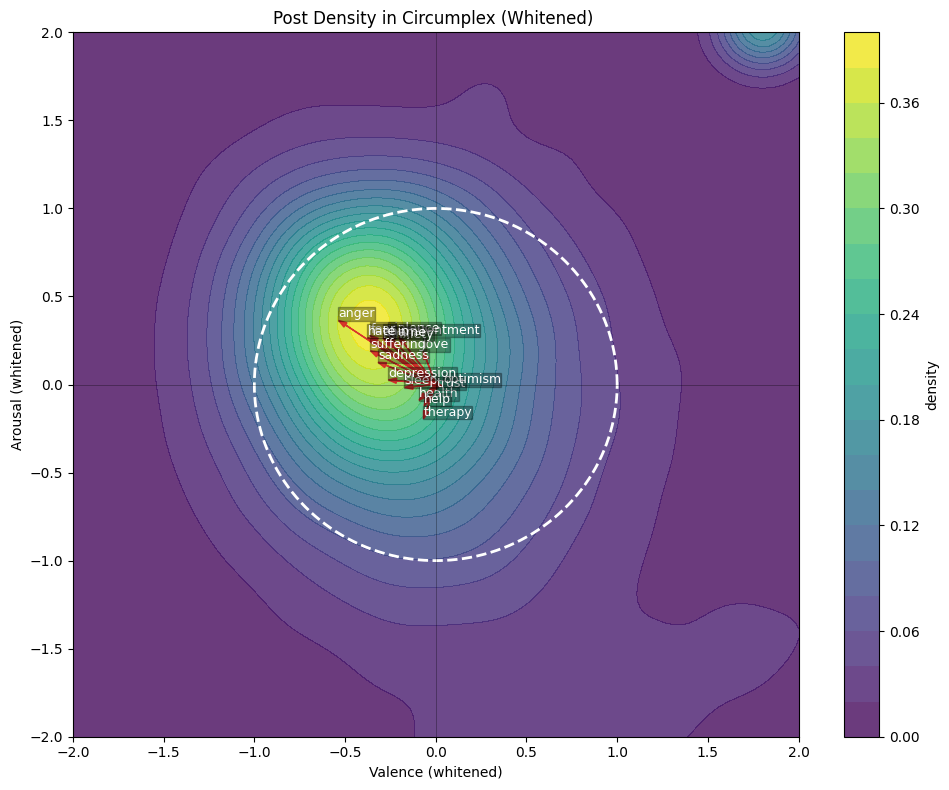

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Post Density in Circumplex (Whitened) '}, xlabel='Valence (whitened)', ylabel='Arousal (whitened)'>)

In [ ]:
def density_plot(mapped_df, cat_vectors_z, title_suffix=""):
    """circumplex visualization with density and category vectors (whitened space).
    Uses a KDE for post density and overlays category vectors (cat_vectors_z).
    Returns (fig, ax) so callers can further modify or save the figure.
    """
    from scipy.stats import gaussian_kde

    fig, ax1 = plt.subplots(figsize=(10, 8))

    # Prepare points for KDE
    pts_df = mapped_df[['valence_w', 'arousal_w']].dropna()
    if len(pts_df) < 10:
        ax1.text(0.5, 0.5, "Not enough data for density", ha='center', va='center')
        ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2)
        _unit_circle(ax1, 1.0, color='white', ls='--', lw=2)
        return fig, ax1

    points = pts_df.values.T
    kde = gaussian_kde(points)

    # grid for density
    xlim = (-2, 2)
    ylim = (-2, 2)
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                         np.linspace(ylim[0], ylim[1], 100))
    density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    im1 = ax1.contourf(xx, yy, density, levels=20, cmap='viridis', alpha=0.8)
    fig.colorbar(im1, ax=ax1, label='density')

    ax1.set_title(f'Post Density in Circumplex (Whitened) {title_suffix}')
    ax1.set_xlabel('Valence (whitened)')
    ax1.set_ylabel('Arousal (whitened)')

    # unit circle and axes
    _unit_circle(ax1, 1.0, color='white', ls='--', lw=2)
    ax1.axhline(0, color='k', lw=0.7, alpha=0.3)
    ax1.axvline(0, color='k', lw=0.7, alpha=0.3)
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)

    # overlay category vectors
    if cat_vectors_z is not None and not cat_vectors_z.empty:
        for _, r in cat_vectors_z.iterrows():
            vx, vy = float(r['vx']), float(r['vy'])
            # draw arrow and label; use contrasting color
            ax1.arrow(0, 0, vx, vy, length_includes_head=True,
                      head_width=0.03, fc='tab:red', ec='tab:red', alpha=0.9)
            ax1.text(vx, vy, r['cat'], fontsize=9, color='white',
                     ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.3, pad=0.2))

    plt.tight_layout()
    plt.show()
    return fig, ax1

density_plot(mapped, cat_vectors_z)

Here the plot shows KDE density contours of posts in whitened valence-arousal space. Category vectors (red arrows) shows directional positions of emotions and white dashed circle is the reference for standardized distances.
The whitened space removes correlations and scale differences between valence/arousal, making directional comparisons fair and preventing axis-scale bias in angular analyses High-density regions (yellow/green) indicate where most posts cluster emotionally.

## 3.2. Quadrant

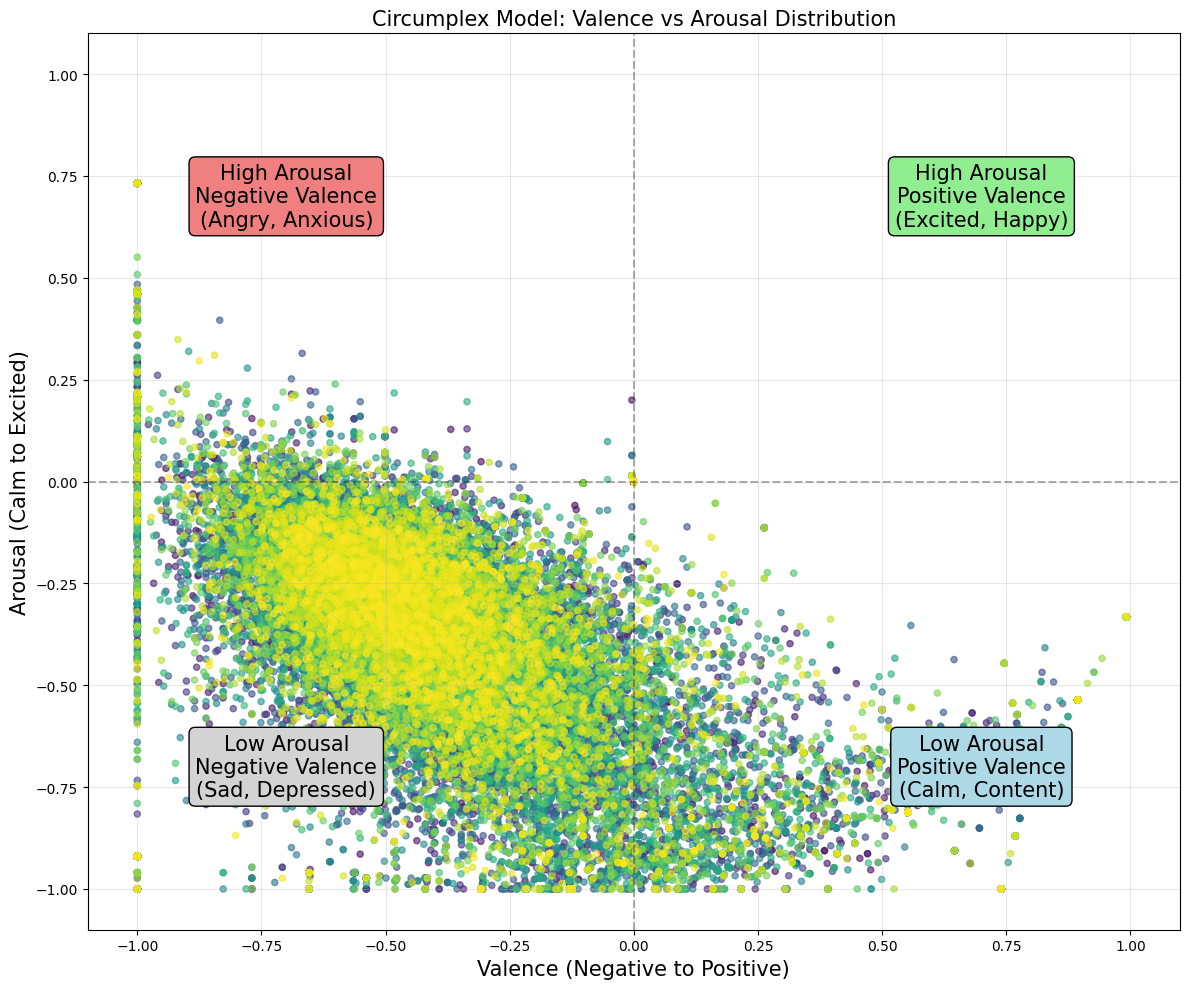

In [71]:
# Create a scatter plot of the circumplex space
plt.figure(figsize=(12, 10))
scatter = plt.scatter(mapped['valence'], mapped['arousal'], 
                     c=mapped.index, alpha=0.6, s=20, cmap='viridis')
plt.xlabel('Valence (Negative to Positive)', fontsize=15, alpha=1.0)
plt.ylabel('Arousal (Calm to Excited)', fontsize=15, alpha=1.0)
plt.title('Circumplex Model: Valence vs Arousal Distribution', fontsize=15, alpha=1.0)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)

plt.xlim(-1.1, 1.1) 
plt.ylim(-1.1, 1.1)

plt.text(0.7, 0.7, 'High Arousal\nPositive Valence\n(Excited, Happy)', 
         ha='center', va='center', fontsize=15, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=1.0))
plt.text(-0.7, 0.7, 'High Arousal\nNegative Valence\n(Angry, Anxious)', 
         ha='center', va='center', fontsize=15, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=1.0))
plt.text(0.7, -0.7, 'Low Arousal\nPositive Valence\n(Calm, Content)', 
         ha='center', va='center', fontsize=15, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=1.0))
plt.text(-0.7, -0.7, 'Low Arousal\nNegative Valence\n(Sad, Depressed)', 
         ha='center', va='center', fontsize=15, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=1.0))

plt.tight_layout()
plt.show()

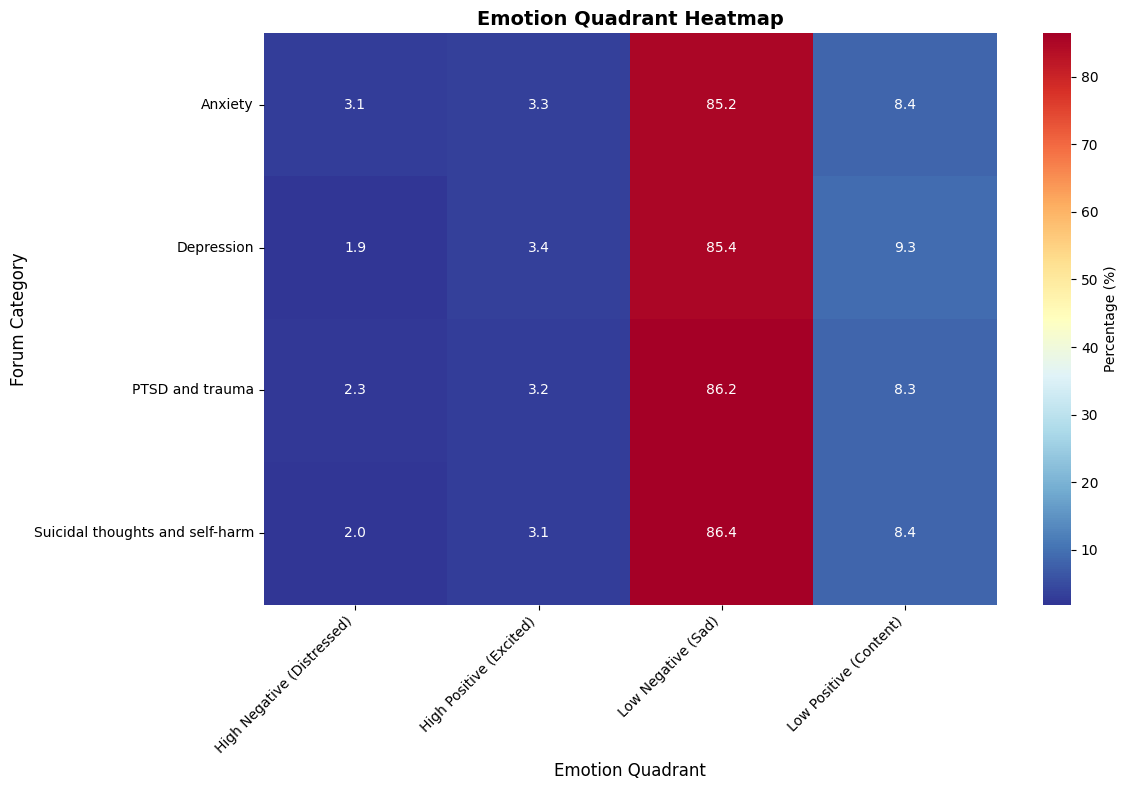

In [19]:
plt.figure(figsize=(12, 8))

forum_quadrant_crosstab = pd.crosstab(mapped['category'], mapped['quadrant'], normalize='index') * 100

import seaborn as sns
sns.heatmap(forum_quadrant_crosstab, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Percentage (%)'})
plt.title('Emotion Quadrant Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Quadrant', fontsize=12)
plt.ylabel('Forum Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The raw circumplex scatter shows a strong concentration in the low-valence / low-arousal quadrant (sad–depressed), with a broad negative skew and only sparse points in high-positive areas. You can also see a thin tail into low-arousal positive (calm/content) and a small wedge of high-arousal negative (angry/anxious).

## 3.3. Circularity diagnostics
After z-scoring, valence_z and arousal_z each have mean 0 and sd 1, but they can still be correlated and unequally dispersed by direction. This is the reason we use whitening in this part. Whitening applies a single linear transform so that the covariance of [valence, arousal] becomes the identity matrix: Cov(Vw, Aw) = I.

In [20]:
def mean_angle(col, thr=0.02, weight=True):
    m = mapped[col] >= thr
    if not m.any():
        return np.nan
    w = mapped.loc[m, col].clip(lower=0.0) if weight else None
    vx = np.average(mapped.loc[m, 'valence_w'], weights=w)
    vy = np.average(mapped.loc[m, 'arousal_w'], weights=w)
    return np.degrees(np.arctan2(vy, vx))

pairs = [
    ('empath_optimism', 'empath_fear'),
    ('empath_trust',    'empath_sadness'),
    ('empath_love',     'empath_hate'),
]
THR = 0.02

for a, b in pairs:
    ang_a = mean_angle(a, thr=THR)
    ang_b = mean_angle(b, thr=THR)
    if np.isnan(ang_a) or np.isnan(ang_b):
        print(f"{a} vs {b}: insufficient data after threshold")
        continue
    delta = abs((ang_a - ang_b + 180) % 360 - 180)
    print(f"{a} vs {b} mean-angle ~ {delta:.1f} degree")

empath_optimism vs empath_fear mean-angle ~ 144.3 degree
empath_trust vs empath_sadness mean-angle ~ 161.7 degree
empath_love vs empath_hate mean-angle ~ 78.1 degree


Here we just quick check to see if thery're roughly opposite. Later we will have a fully validation.

Valence w mean~ -0.0 sd~ 1.0
Arousal w  mean~ 0.0 sd~ 1.0
Radius    mean~ 1.139 sd~ 0.838
Resultant length R=0.169, circular std≈108.0 degree


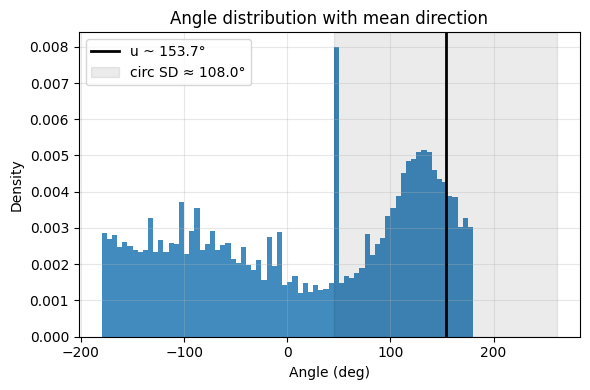

In [21]:
# Circular statistics
print("Valence w mean~", mapped['valence_w'].mean().round(3), "sd~", mapped['valence_w'].std(ddof=0).round(3))
print("Arousal w  mean~", mapped['arousal_w'].mean().round(3), "sd~", mapped['arousal_w'].std(ddof=0).round(3))
print("Radius    mean~",  mapped['radius_w'].mean().round(3),     "sd~", mapped['radius_w'].std(ddof=0).round(3))

theta = mapped['angle_w'].to_numpy()
C = np.mean(np.cos(theta)); S = np.mean(np.sin(theta))
R = np.hypot(C, S)
circ_std_rad = np.sqrt(-2*np.log(max(R, 1e-12)))
circ_sd_deg = np.degrees(circ_std_rad)
mu_deg = np.degrees(np.arctan2(S, C))
print(f"Resultant length R={R:.3f}, circular std≈{circ_sd_deg:.1f} degree")

 
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(np.degrees(theta), bins=72, range=(-180, 180), density=True, alpha=0.85)
ax.axvline(mu_deg, color='k', lw=2, label=f"u ~ {mu_deg:.1f}°")
ax.axvspan(mu_deg - circ_sd_deg, mu_deg + circ_sd_deg, color='k', alpha=0.08,
           label=f"circ SD ≈ {circ_sd_deg:.1f}°")
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Density')
ax.set_title('Angle distribution with mean direction')
ax.legend()
ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

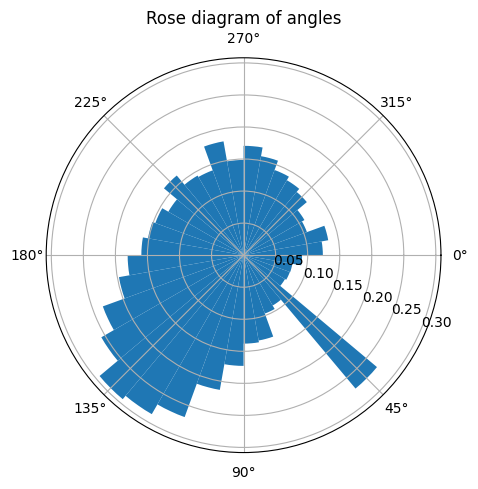

In [ ]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('E')  
ax.set_theta_direction(-1)      
ax.hist(theta, bins=36, range=(-np.pi, np.pi), density=True)
ax.set_title('Rose diagram of angles')
plt.tight_layout(); plt.show()

Angle distribution becomes more uniform after whitening

In [ ]:
# Circular Distribution
def circular_distribution(df):
    """Check if the valence-arousal distribution forms a circular pattern"""
    
    # Calculate distance from origin for each point
    distances = np.sqrt(df['valence_w']**2 + df['arousal_w']**2)
    angles = np.arctan2(df['arousal_w'], df['valence_w'])

    print(f"Mean distance from origin: {distances.mean():.3f} (±{distances.std():.3f})")
    print(f"Distance range: {distances.min():.3f} to {distances.max():.3f}")
    
    # Check if points are roughly equidistant from origin 
    distance_cv = distances.std() / distances.mean()  # Coefficient of variation
    print(f"Distance coefficient of variation: {distance_cv:.3f}")
    print(f"Circular distribution quality: {'Good' if distance_cv < 0.5 else 'Poor'}")
    
    return distances, angles

distances, angles = circular_distribution(mapped)

Mean distance from origin: 1.139 (±0.838)
Distance range: 0.002 to 5.245
Distance coefficient of variation: 0.735
Circular distribution quality: Poor


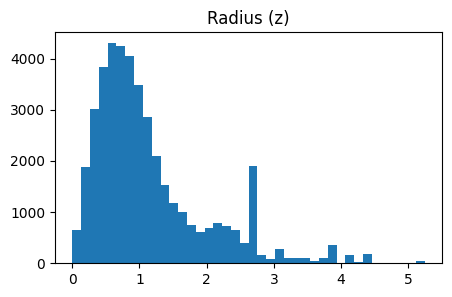

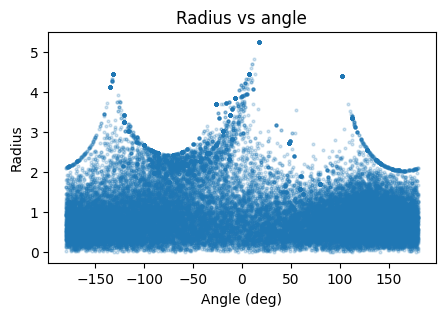

In [24]:
plt.figure(figsize=(5,3)); plt.hist(distances, bins=40); plt.title('Radius (z)'); plt.show()
plt.figure(figsize=(5,3)); plt.scatter(np.degrees(angles), distances, s=4, alpha=.2)
plt.xlabel('Angle (deg)'); plt.ylabel('Radius'); plt.title('Radius vs angle'); plt.show()

## 3.4. Opposite Pair Validation

In [ ]:
def _angle_deg(xy):
    return float(np.degrees(np.arctan2(xy[1], xy[0])))

def _angle_sep_deg(xy1, xy2):
    # smallest absolute angular difference in degrees
    return float(abs((_angle_deg(xy1) - _angle_deg(xy2) + 180) % 360 - 180))

def _euclid(a, b):
    return float(np.hypot(a[0]-b[0], a[1]-b[1]))

def mean_coords_weighted(
    df, name, *, prefix='empath_', thr=0.02,
    v_col='valence_w', a_col='arousal_w'
    ):
    """
    Weighted mean for posts where the empath category is present
    """
    col = f"{prefix}{name}"
    if col not in df.columns:
        return None, 0
    m = df[col] > thr
    n = int(m.sum())
    if n == 0:
        return None, 0
    w = df.loc[m, col].clip(lower=thr)
    v = float(np.average(df.loc[m, v_col], weights=w))
    a = float(np.average(df.loc[m, a_col], weights=w))
    return (v, a), n

def coords_from_map(name, circ):
    """
    Get category (valence, arousal) from your CircumplexMapping
    """
    try:
        v, a = circ.map_single_category(name)
        return (float(v), float(a))
    except Exception:
        return None
    
def opposite_emotions(
    df,
    circ,
    pairs=None,                 # list[(name_a, name_b)]
    prefix="empath_",
    thr=0.02,
    use_data=True,             
    min_posts=0,             
    v_col='valence_w',
    a_col='arousal_w'
    ):
    if pairs is None:
        pairs = [
            ('joy','sadness'),
            ('happiness','depression'),
            ('excitement','calm'),
            ('love','hate'),
            ('anger','peace'),
            ('anxiety','relaxation'),
            ('fear','confidence'),
            ('positive_emotion','negative_emotion'),
        ]
    
    rows = []
    for a, b in pairs:
        if use_data:
            A, n_a = mean_coords_weighted(df, a, prefix=prefix, thr=thr, v_col=v_col, a_col=a_col)
            B, n_b = mean_coords_weighted(df, b, prefix=prefix, thr=thr, v_col=v_col, a_col=a_col)
            src_a, src_b = ('data', 'data')
            valid = (A is not None) and (B is not None) and (n_a >= min_posts) and (n_b >= min_posts)
        else:
            A, B = coords_from_map(a, circ), coords_from_map(b, circ)
            n_a = n_b = 0
            src_a = src_b = 'map'
            valid = (A is not None) and (B is not None)

        if not valid:
            rows.append({
                'pair': f'{a} vs {b}', 'a': a, 'b': b,
                'angle_deg': np.nan, 'distance': np.nan,
                'coords_a': A, 'coords_b': B,
                'source_a': src_a, 'source_b': src_b,
                'n_a': n_a, 'n_b': n_b
            })
            continue

        rows.append({
            'pair': f'{a} vs {b}', 'a': a, 'b': b,
            'angle_deg': _angle_sep_deg(A, B),
            'distance': _euclid(A, B),
            'coords_a': A, 'coords_b': B,
            'source_a': src_a, 'source_b': src_b,
            'n_a': n_a, 'n_b': n_b
        })

    res = pd.DataFrame(rows).sort_values('angle_deg', ascending=False)
    ok = int((res['angle_deg'] >= 120).sum())
    print(f"Opposite pairs with angle≥120°: {ok}/{len(res)} "
          f"(use_data={use_data}, thr={thr}, min_posts={min_posts}, space=({v_col},{a_col}) if data)")
    return res

def best_opposites(
    df, kept, *, prefix='empath_', thr=0.02, min_posts=0,
    v_col='valence_w', a_col='arousal_w'):
    """
    For each kept category, find the other kept category with the largest angle
    """
    coords, counts = {}, {}
    for c in kept:
        xy, n = mean_coords_weighted(df, c, prefix=prefix, thr=thr, v_col=v_col, a_col=a_col)
        coords[c], counts[c] = xy, n

    out = []
    for a in kept:
        A = coords.get(a)
        if (A is None) or (counts[a] < min_posts):
            continue
        best = None
        for b in kept:
            if a == b:
                continue
            B = coords.get(b)
            if (B is None) or (counts[b] < min_posts):
                continue
            ang = _angle_sep_deg(A, B)
            if (best is None) or (ang > best[0]):
                best = (ang, b)
        if best:
            out.append({'a': a, 'best_opposite': best[1], 'angle_deg': best[0],
                        'n_a': counts[a], 'n_b': counts[best[1]]})
    return pd.DataFrame(out).sort_values('angle_deg', ascending=False)

def summarize_pairs(df, label):
    total = len(df)
    good  = int((df['angle_deg'] >= 120).sum())
    worst = float(df['angle_deg'].min()) if total and df['angle_deg'].notna().any() else np.nan
    print(f"{label}: {good}/{total} pairs ≥120°, min angle = {worst:.1f}°")

anchor_pairs = [
    ('joy','sadness'),
    ('happiness','depression'),
    ('excitement','calm'),
    ('love','hate'),
    ('anger','peace'),
    ('anxiety','relaxation'),
    ('fear','confidence'),
    ('positive_emotion','negative_emotion'),
]
opp_map = opposite_emotions(mapped, circ, pairs=anchor_pairs, use_data=False)
display(opp_map[['pair','angle_deg','distance','source_a','source_b']])
summarize_pairs(opp_map, "Anchors (map-only)")

Opposite pairs with angle≥120°: 7/8 (use_data=False, thr=0.02, min_posts=0, space=(valence_w,arousal_w) if data)


,pair,angle_deg,distance,source_a,source_b
3,love vs hate,173.245753,2.063895,map,map
4,anger vs peace,155.985563,2.378757,map,map
0,joy vs sadness,152.835015,2.316466,map,map
6,fear vs confidence,149.694500,2.284840,map,map
5,anxiety vs relaxation,140.899616,2.087502,map,map
1,happiness vs depression,132.486852,2.026007,map,map
7,positive_emotion vs negative_emotion,131.103263,1.304443,map,map
2,excitement vs calm,39.109374,0.740778,map,map


Anchors (map-only): 7/8 pairs ≥120°, min angle = 39.1°


We use only the NRC-VAD anchor coordinates(no data) to verify that our canonical opposite pairs are geometrically opposite in the circumplex. If the angle comes to 180, it is the perfect opposition. Distance is the Euclidean distance between the two anchor points(bigger= more seperated). There are 7/8 pairs larger than 120 degree and min angle ~ 39, which means anchors largely consistent; one noisy pair highlights where our hand-mapping is weakest.


In [26]:
THR = 0.03
MIN_POSTS = 100

proposed_pairs = [
    ('positive_emotion','negative_emotion'),
    ('optimism','fear'),
    ('trust','hate'),
    ('love','sadness'),
    ('anxiety','optimism'),
    ('anger','trust'),
    ('violence','help'),
    ('shame','optimism'),
]
kept = sorted({c.replace('empath_','') for c in mapped.columns if c.startswith('empath_')})
data_pairs = [(a,b) for (a,b) in proposed_pairs if a in kept and b in kept]

opp_data = opposite_emotions(
    mapped, circ,
    pairs=data_pairs, thr=THR, use_data=True, min_posts=MIN_POSTS,
    v_col='valence_w', a_col='arousal_w'
)
display(opp_data[['pair','angle_deg','distance','n_a','n_b','source_a','source_b']]
        .sort_values('angle_deg', ascending=False))
summarize_pairs(opp_data, "Kept categories (data-driven, whitened)")

best_df = best_opposites(mapped, kept, thr=THR, min_posts=MIN_POSTS,
                         v_col='valence_w', a_col='arousal_w')
display(best_df.head(15))

Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.03, min_posts=100, space=(valence_w,arousal_w) if data)


,pair,angle_deg,distance,n_a,n_b,source_a,source_b
4,anger vs trust,172.907130,1.532585,2635,6506,data,data
1,trust vs hate,170.874789,1.337032,6506,7147,data,data
5,violence vs help,150.153333,1.295330,12859,12094,data,data
0,optimism vs fear,143.451837,1.135017,13992,9461,data,data
3,anxiety vs optimism,129.387210,1.028097,21777,13992,data,data
6,shame vs optimism,129.106896,1.023932,14960,13992,data,data
2,love vs sadness,106.273463,0.952542,11372,14738,data,data


Kept categories (data-driven, whitened): 6/7 pairs ≥120°, min angle = 106.3°


,a,best_opposite,angle_deg,n_a,n_b
9,optimism,sadness,174.136459,13992,14738
11,sadness,optimism,174.136459,14738,13992
16,trust,suffering,172.978778,6506,11689
14,suffering,trust,172.978778,11689,6506
0,anger,trust,172.907130,2635,6506
5,hate,trust,170.874789,7147,6506
4,fear,trust,166.415853,9461,6506
8,love,sleep,163.515073,11372,1956
13,sleep,love,163.515073,1956,11372
6,health,love,162.423056,14858,11372


In [27]:
for thr in (0.02, 0.03, 0.05):
    for m in (50, 100, 200):
        opp = opposite_emotions(mapped, circ,
                                pairs=data_pairs, prefix='empath_',
                                thr=thr, use_data=True, min_posts=m)
        ok = (opp['angle_deg']>=120).sum()
        print(f"thr={thr:.2f}, min_posts={m}: {ok}/{len(opp)} pairs ≥120°, min Δ={opp['angle_deg'].min():.1f}°, "
              f"median dist={opp['distance'].median():.2f}")

Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.02, min_posts=50, space=(valence_w,arousal_w) if data)
thr=0.02, min_posts=50: 6/7 pairs ≥120°, min Δ=104.0°, median dist=1.00
Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.02, min_posts=100, space=(valence_w,arousal_w) if data)
thr=0.02, min_posts=100: 6/7 pairs ≥120°, min Δ=104.0°, median dist=1.00
Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.02, min_posts=200, space=(valence_w,arousal_w) if data)
thr=0.02, min_posts=200: 6/7 pairs ≥120°, min Δ=104.0°, median dist=1.00
Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.03, min_posts=50, space=(valence_w,arousal_w) if data)
thr=0.03, min_posts=50: 6/7 pairs ≥120°, min Δ=106.3°, median dist=1.14
Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.03, min_posts=100, space=(valence_w,arousal_w) if data)
thr=0.03, min_posts=100: 6/7 pairs ≥120°, min Δ=106.3°, median dist=1.14
Opposite pairs with angle≥120°: 6/7 (use_data=True, thr=0.03, min_pos

We will take thr=0.03, min_post=100 as a good balance as it gives us high coverage with clearly separated pairs and matches the pattern in the grid.

In [ ]:
def one_to_one_pairs(df_best, kept, angle_min=140, min_posts=100):
    """
    Takes the output and returns an optimal one-to-one pairing subject to angle_min & min_posts on both sides.
    """
    # Filter usable rows
    usable = (
        df_best.query("a in @kept and best_opposite in @kept")
               .query("angle_deg >= @angle_min and n_a >= @min_posts and n_b >= @min_posts")
               .copy()
    )
    if usable.empty:
        return [], pd.DataFrame(columns=['a','b','angle_deg','n_a','n_b'])

    # Build cost matrix 
    from scipy.optimize import linear_sum_assignment

    L = sorted(usable['a'].unique())
    R = sorted(usable['best_opposite'].unique())

    # map to indices
    Li = {x:i for i,x in enumerate(L)}
    Ri = {x:i for i,x in enumerate(R)}

    # initialize with a large penalty for impossible edges
    K = max(len(L), len(R))
    PEN = 1e6
    cost = np.full((K, K), PEN, dtype=float)

    # fill costs with angle
    for _, r in usable.iterrows():
        i = Li[r['a']]
        j = Ri[r['best_opposite']]
        cost[i, j] = -float(r['angle_deg'])

    # run assignment
    rows, cols = linear_sum_assignment(cost)

    chosen = []
    for i, j in zip(rows, cols):
        if i >= len(L) or j >= len(R):
            continue
        a = L[i]
        b = R[j]
        ang = usable.query("a == @a and best_opposite == @b")['angle_deg']
        if ang.empty:
            continue
        angle = float(ang.iloc[0])
        if angle < angle_min:
            continue
        n_a = int(usable.query("a == @a and best_opposite == @b")['n_a'].iloc[0])
        n_b = int(usable.query("a == @a and best_opposite == @b")['n_b'].iloc[0])
        chosen.append((a, b, angle, n_a, n_b))
    pairs_df = pd.DataFrame(chosen, columns=['a','b','angle_deg','n_a','n_b']) \
                .sort_values('angle_deg', ascending=False)

    pairs = [(r.a, r.b) for r in pairs_df.itertuples(index=False)]
    return pairs, pairs_df

pairs_1to1, pairs_table = one_to_one_pairs(best_df, kept, angle_min=140, min_posts=MIN_POSTS)
display(pairs_table)

opp_1to1 = opposite_emotions(mapped, circ, pairs=pairs_1to1,
                             prefix='empath_', thr=THR, use_data=True, min_posts=MIN_POSTS)
display(opp_1to1[['pair','angle_deg','distance','n_a','n_b']].sort_values('angle_deg'))
ok = int((opp_1to1['angle_deg'] >= 120).sum())
print(f"Pass ≥120°: {ok}/{len(opp_1to1)}; min Δ={opp_1to1['angle_deg'].min():.1f}°, "
      f"median dist={opp_1to1['distance'].median():.2f}")

,a,b,angle_deg,n_a,n_b
3,optimism,sadness,174.136459,13992,14738
4,sadness,optimism,174.136459,14738,13992
6,suffering,trust,172.978778,11689,6506
7,trust,suffering,172.978778,6506,11689
2,love,sleep,163.515073,11372,1956
5,sleep,love,163.515073,1956,11372
0,contentment,help,161.742301,10827,12094
1,help,contentment,161.742301,12094,10827


Opposite pairs with angle≥120°: 8/8 (use_data=True, thr=0.03, min_posts=100, space=(valence_w,arousal_w) if data)


,pair,angle_deg,distance,n_a,n_b
6,contentment vs help,161.742301,1.162036,10827,12094
7,help vs contentment,161.742301,1.162036,12094,10827
5,sleep vs love,163.515073,1.150780,1956,11372
4,love vs sleep,163.515073,1.150780,11372,1956
2,suffering vs trust,172.978778,1.263875,11689,6506
3,trust vs suffering,172.978778,1.263875,6506,11689
0,optimism vs sadness,174.136459,1.100437,13992,14738
1,sadness vs optimism,174.136459,1.100437,14738,13992


Pass ≥120°: 8/8; min Δ=161.7°, median dist=1.16


The opposite-pair tests show large angular separation (>120), which matches expectations for these categories.

In [29]:
def validate_circumplex_structure(df, pairs):
    """Comprehensive validation of circumplex structure"""
    from scipy.stats import pearsonr, circmean, circstd
    import numpy as np
    
    results = {}
    
    # Test orthogonality of valence/arousal after whitening
    corr_vw_aw = pearsonr(df['valence_w'], df['arousal_w'])[0]
    results['orthogonality'] = abs(corr_vw_aw) < 0.05  # Should be near zero

    # Test uniformity of angle distribution
    from scipy.stats import kstest
    angles = df['angle_w'].values
    uniform_angles = np.random.uniform(-np.pi, np.pi, len(angles))
    ks_stat, ks_p = kstest(angles, uniform_angles)
    results['angle_uniformity'] = {'ks_stat': ks_stat, 'p_value': ks_p}

    # Validate opposite pairs more rigorously
    angle_threshold = 120  # degrees
    good_pairs = (pairs['angle_deg'] >= angle_threshold).sum()
    results['opposite_validation'] = {
        'good_pairs': good_pairs,
        'total_pairs': len(pairs),
        'success_rate': good_pairs / len(pairs)
    }

    
    theoretical_consistency = []
    for _, row in pairs.iterrows():
        if not pd.isna(row['angle_deg']):
            theoretical_consistency.append(row['angle_deg'] >= angle_threshold)
    
    results['theoretical_consistency'] = np.mean(theoretical_consistency) if theoretical_consistency else 0
    
    return results

validation_results = validate_circumplex_structure(mapped, opp_data)
print("Circumplex Validation Results:")
for key, value in validation_results.items():
    print(f"  {key}: {value}")

Circumplex Validation Results:
  orthogonality: True
  angle_uniformity: {'ks_stat': 0.11532653831634576, 'p_value': 5.278582589954691e-246}
  opposite_validation: {'good_pairs': 6, 'total_pairs': 7, 'success_rate': 0.8571428571428571}
  theoretical_consistency: 0.8571428571428571


In [30]:
def robustness_analysis(mapped_df, n_bootstraps=100):
    """Test stability of circumplex mapping across subsamples"""
    
    # Get actual categories from your data instead of hardcoded ones
    empath_cols = [col for col in mapped_df.columns if col.startswith('empath_')]
    key_categories = [col.replace('empath_', '') for col in empath_cols]
    
    min_threshold_posts = 18
    valid_categories = []
    for cat in key_categories:
        col = f'empath_{cat}'
        if (mapped_df[col] > 0.02).sum() >= min_threshold_posts:
            valid_categories.append(cat)
    
    print(f"Testing robustness for {len(valid_categories)} categories: {valid_categories}")
    
    results = []
    
    for i in range(n_bootstraps):
        # 80% bootstrap sample
        sample = mapped_df.sample(frac=0.8, random_state=i)

        # Recompute whitening on sample
        Z_sample = sample[['valence_z', 'arousal_z']].values
        Sigma_sample = np.cov(Z_sample, rowvar=False)
        w_sample, V_sample = np.linalg.eigh(Sigma_sample)
        W_sample = V_sample @ np.diag(1/np.sqrt(w_sample + 1e-12)) @ V_sample.T
        
        # Apply whitening
        Zw_sample = Z_sample @ W_sample.T
        sample_copy = sample.copy()
        sample_copy['valence_w'] = Zw_sample[:, 0]
        sample_copy['arousal_w'] = Zw_sample[:, 1]
        
        # Compute positions for valid categories
        positions = {}
        for cat in valid_categories:
            col = f'empath_{cat}'
            if col in sample_copy.columns:
                mask = sample_copy[col] > 0.02
                if mask.sum() >= 30:  # Lower threshold for bootstrap samples
                    pos = sample_copy.loc[mask, ['valence_w', 'arousal_w']].mean()
                    positions[cat] = (pos['valence_w'], pos['arousal_w'])
        
        results.append(positions)
    
    # Analyze stability
    stability_summary = {}
    for cat in valid_categories:
        positions = [r[cat] for r in results if cat in r]
        if positions:
            positions = np.array(positions)
            stability_summary[cat] = {
                'mean_pos': positions.mean(axis=0),
                'std_pos': positions.std(axis=0),
                'n_samples': len(positions)
            }
    
    return stability_summary

# Run robustness check
stability = robustness_analysis(mapped)
print("\nStability Analysis:")
for cat, stats in stability.items():
    print(f"{cat}: std_v={stats['std_pos'][0]:.3f}, std_a={stats['std_pos'][1]:.3f} (n={stats['n_samples']})")

if stability:
    stability_scores = {cat: np.mean(stats['std_pos']) for cat, stats in stability.items()}
    most_stable = sorted(stability_scores.items(), key=lambda x: x[1])[:5]
    print(f"\nMost stable categories:")
    for cat, avg_std in most_stable:
        print(f"  {cat}: avg_std={avg_std:.3f}")

Testing robustness for 18 categories: ['anxiety', 'pain', 'violence', 'sadness', 'depression', 'help', 'love', 'suffering', 'health', 'contentment', 'fear', 'trust', 'hate', 'therapy', 'sleep', 'anger', 'shame', 'optimism']

Stability Analysis:
anxiety: std_v=0.002, std_a=0.002 (n=100)
pain: std_v=0.002, std_a=0.002 (n=100)
violence: std_v=0.002, std_a=0.002 (n=100)
sadness: std_v=0.002, std_a=0.002 (n=100)
depression: std_v=0.003, std_a=0.002 (n=100)
help: std_v=0.003, std_a=0.003 (n=100)
love: std_v=0.003, std_a=0.002 (n=100)
suffering: std_v=0.002, std_a=0.002 (n=100)
health: std_v=0.002, std_a=0.003 (n=100)
contentment: std_v=0.002, std_a=0.002 (n=100)
fear: std_v=0.002, std_a=0.002 (n=100)
trust: std_v=0.004, std_a=0.004 (n=100)
hate: std_v=0.002, std_a=0.002 (n=100)
therapy: std_v=0.003, std_a=0.003 (n=100)
sleep: std_v=0.008, std_a=0.007 (n=100)
anger: std_v=0.004, std_a=0.004 (n=100)
shame: std_v=0.002, std_a=0.002 (n=100)
optimism: std_v=0.003, std_a=0.003 (n=100)

Most stable

Here we found that all 18 categories we pick from VAD show remarkably low positional variance. Average std_dev range is between 0.002-0.008 in whitened space.  This represents <1% movement relative to typical circumplex distances.

In [31]:
def safe_mean_coords_weighted(df, name, **kwargs):
    """Safe version with proper error handling"""
    try:
        result = mean_coords_weighted(df, name, **kwargs)
        return result
    except Exception as e:
        print(f"Warning: Failed to compute coordinates for {name}: {e}")
        return None, 0

# Add validation for your whitening matrix
def validate_whitening_matrix(W, Z):
    """Ensure whitening matrix is valid"""
    if np.any(np.isnan(W)) or np.any(np.isinf(W)):
        raise ValueError("Whitening matrix contains NaN or inf values")
    
    # Test on small sample
    test_sample = Z[:100] @ W.T
    test_cov = np.cov(test_sample, rowvar=False)
    
    if not np.allclose(test_cov, np.eye(2), atol=1e-2):
        print("Warning: Whitening may not be working correctly")
        print(f"Expected identity matrix, got:\n{test_cov}")

# Use before applying whitening
validate_whitening_matrix(W, Z)

Expected identity matrix, got:
[[0.71909882 0.03943547]
 [0.03943547 0.78550337]]


Most similar pairs (top 10):
          a           b      cos
    anxiety       anger 1.000000
    sadness  depression 0.999706
      trust      health 0.997879
    anxiety        fear 0.993533
       fear       anger 0.993533
  suffering       shame 0.990949
contentment      health 0.988131
       pain   suffering 0.988006
   optimism contentment 0.987329
contentment       trust 0.976037

Most opposite pairs (top 10):
        a           b       cos
     fear        love -0.999599
    anger        love -0.989920
  anxiety        love -0.989920
 violence    optimism -0.980636
     pain        love -0.960562
 violence contentment -0.937134
suffering        love -0.906103
 violence        love -0.901243
  anxiety    optimism -0.876057
    anger    optimism -0.876057


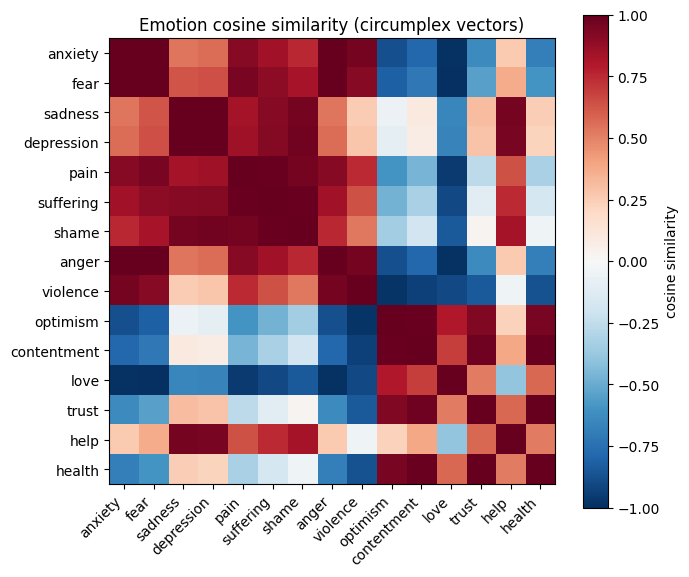

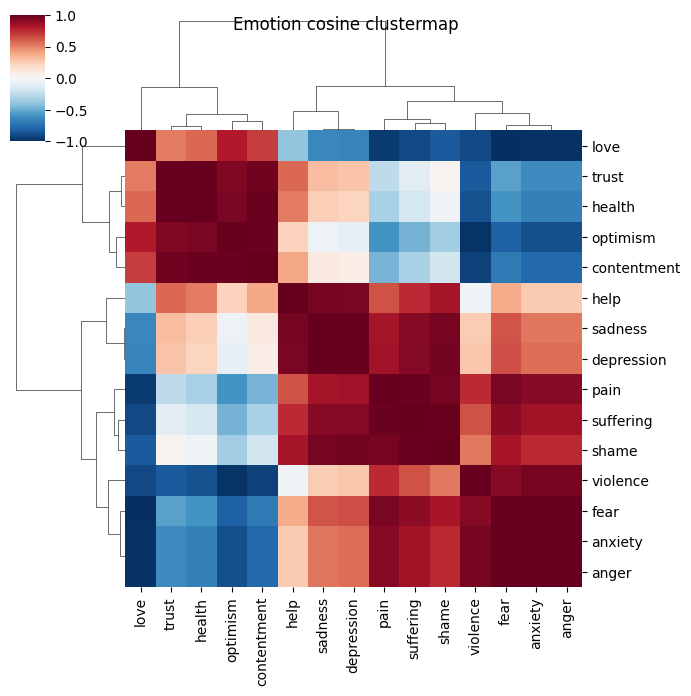

In [ ]:
from itertools import combinations
import numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

def emotion_cosine_analysis(df, circ, emotions=None, W=None):
    # choose emotions
    if emotions is None:
        # fixed, interpretable set
        emotions = [
            'anxiety','fear','sadness','depression','pain','suffering','shame','anger','violence',
            'optimism','contentment','love','trust','help','health'
        ]
    # keep only those present
    cols = [f'empath_{e}' for e in emotions if f'empath_{e}' in df.columns]
    names = [c.replace('empath_', '') for c in cols]

    # get (v,a) for each category from the mapping
    vecs = []
    for e in names:
        v, a = circ.map_single_category(f'empath_{e}')
        vecs.append([v, a])
    V = np.array(vecs, dtype=float)
    
    if W is not None:                                    
        V = (W @ V.T).T

    # cosine similarity 
    C = cosine_similarity(V, V)
    cos_df = pd.DataFrame(C, index=names, columns=names)

    # summarize extremes
    pairs = [{'a': names[i], 'b': names[j], 'cos': C[i, j]}
             for i, j in combinations(range(len(names)), 2)]
    pairs_df     = pd.DataFrame(pairs).sort_values('cos', ascending=False, ignore_index=True)
    most_similar = pairs_df.head(10)
    most_opposite = pairs_df.tail(10).sort_values('cos', ascending=True)

    print("Most similar pairs (top 10):")
    print(most_similar.to_string(index=False))
    print("\nMost opposite pairs (top 10):")
    print(most_opposite.to_string(index=False))

    # quick plot
    plt.figure(figsize=(7,6))
    im = plt.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
    plt.colorbar(im, label='cosine similarity')
    plt.xticks(range(len(names)), names, rotation=45, ha='right')
    plt.yticks(range(len(names)), names)
    plt.title('Emotion cosine similarity (circumplex vectors)')
    plt.tight_layout(); plt.show()

    # clustermap
    try:
        cg = sns.clustermap(cos_df, cmap='RdBu_r', vmin=-1, vmax=1, figsize=(7,7))
        cg.fig.suptitle('Emotion cosine clustermap'); plt.show()
    except Exception:
        pass

    return cos_df, most_similar, most_opposite
cos_df, most_similar, most_opposite = emotion_cosine_analysis(mapped, circ, W=W)

Cosine similarity among circumplex vectors revealed a strong bipolar structure. Two super-clusters emerged: (1) negative/high-arousal emotions (anger, fear, anxiety, violence, shame; sadness, depression, pain, suffering), and (2) positive/prosocial states (love, trust, health, help, contentment, optimism). Within-cluster cosines were high (~0.9–1.0), while across clusters were strongly negative (~−0.8 to −1.0), indicating near-opposite directions in the circumplex.

The most similar pairs (e.g., anxiety–anger; sadness–depression; trust–health; optimism–contentment) corroborate face validity. The most opposite pairs predominantly match positive prosocial states against threat/loss states (e.g., love vs fear/anxiety; optimism vs suffering/pain), consistent with a valence-dominant axis and arousal modulation.

## 3.5. Reliability

In [33]:
# Split-half reliability
from scipy.stats import pearsonr, spearmanr

rng = np.random.default_rng(42)
ix = rng.random(len(mapped)) < 0.5
A, B = mapped.loc[ix], mapped.loc[~ix]

def cat_means(df, min_posts=100):
    cols = [c for c in mapped.columns if c.startswith('empath_')]
    rows = []
    for c in cols:
        subset = df.loc[df[c] > 0, ['valence_z', 'arousal_z']]
        n = len(subset)
        if n >= min_posts:
            m = subset.mean()
            rows.append({'cat': c, 'n': n, 'valence_z': m['valence_z'], 'arousal_z': m['arousal_z']})
    return pd.DataFrame(rows).set_index('cat')

mA = cat_means(A, min_posts=100)
mB = cat_means(B, min_posts=100)
common = mA.index.intersection(mB.index)
r_v_p = pearsonr(mA.loc[common, 'valence_z'], mB.loc[common, 'valence_z'])[0]
r_a_p = pearsonr(mA.loc[common, 'arousal_z'], mB.loc[common, 'arousal_z'])[0]
r_v_s = spearmanr(mA.loc[common, 'valence_z'], mB.loc[common, 'valence_z']).correlation
r_a_s = spearmanr(mA.loc[common, 'arousal_z'], mB.loc[common, 'arousal_z']).correlation

print(f"Split-half reliability (min_posts=100): "
      f"valence r={r_v_p:.3f} (ρ={r_v_s:.3f}), arousal r={r_a_p:.3f} (ρ={r_a_s:.3f}); "
      f"categories compared: {len(common)}")

Split-half reliability (min_posts=100): valence r=0.999 (ρ=0.990), arousal r=1.000 (ρ=0.992); categories compared: 18


Split-half reliability is very high (r~1), so category positions are stable.

## 3.6. User & temporal summaries

In [34]:
weekly_vad = (
    mapped.groupby(['user_id','week'])[['valence','arousal','radius','valence_z','arousal_z','radius_z','valence_w','arousal_w','radius_w']]
          .mean()
          .reset_index()
)
weekly_vad = weekly_vad.sort_values(['user_id','week'])
weekly_vad['valence_4w'] = weekly_vad.groupby('user_id')['valence'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['arousal_4w'] = weekly_vad.groupby('user_id')['arousal'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['radius_4w']  = weekly_vad.groupby('user_id')['radius'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['valence_4w_z'] = weekly_vad.groupby('user_id')['valence_z'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['arousal_4w_z'] = weekly_vad.groupby('user_id')['arousal_z'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['radius_4w_z']  = weekly_vad.groupby('user_id')['radius_z'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['valence_4w_w'] = weekly_vad.groupby('user_id')['valence_w'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['arousal_4w_w'] = weekly_vad.groupby('user_id')['arousal_w'].transform(lambda s: s.rolling(4, min_periods=1).mean())
weekly_vad['radius_4w_w']  = weekly_vad.groupby('user_id')['radius_w'].transform(lambda s: s.rolling(4, min_periods=1).mean())

In [35]:
weekly_vad.head()

,user_id,week,valence,arousal,radius,valence_z,arousal_z,radius_z,valence_w,arousal_w,radius_w,valence_4w,arousal_4w,radius_4w,valence_4w_z,arousal_4w_z,radius_4w_z,valence_4w_w,arousal_4w_w,radius_4w_w
0,1001,2025-07-14,-0.581838,-0.268762,0.642621,-0.673745,0.454293,0.826966,-0.615691,0.307426,0.717833,-0.581838,-0.268762,0.642621,-0.673745,0.454293,0.826966,-0.615691,0.307426,0.717833
1,1002,2025-07-07,0.122000,-0.906000,0.914177,1.621301,-2.060086,2.621559,1.198129,-1.814492,2.174372,0.122000,-0.906000,0.914177,1.621301,-2.060086,2.621559,1.198129,-1.814492,2.174372
2,1002,2025-07-14,-0.146200,-0.403050,0.500136,0.746765,-0.075573,1.175629,0.807889,0.134938,1.144961,-0.012100,-0.654525,0.707157,1.184033,-1.067829,1.898594,1.003009,-0.839777,1.659667
3,1003,2025-07-14,-0.676000,-0.253176,0.721855,-0.980784,0.515790,1.108141,-0.938942,0.285763,0.981464,-0.676000,-0.253176,0.721855,-0.980784,0.515790,1.108141,-0.938942,0.285763,0.981464
4,1004,2023-10-16,-0.401422,-0.180962,0.471455,-0.085450,0.800728,0.995097,0.139780,0.864974,1.067681,-0.401422,-0.180962,0.471455,-0.085450,0.800728,0.995097,0.139780,0.864974,1.067681


In [36]:
weekly_vad

,user_id,week,valence,arousal,radius,valence_z,arousal_z,radius_z,valence_w,arousal_w,radius_w,valence_4w,arousal_4w,radius_4w,valence_4w_z,arousal_4w_z,radius_4w_z,valence_4w_w,arousal_4w_w,radius_4w_w
0,1001,2025-07-14,-0.581838,-0.268762,0.642621,-0.673745,0.454293,0.826966,-0.615691,0.307426,0.717833,-0.581838,-0.268762,0.642621,-0.673745,0.454293,0.826966,-0.615691,0.307426,0.717833
1,1002,2025-07-07,0.122000,-0.906000,0.914177,1.621301,-2.060086,2.621559,1.198129,-1.814492,2.174372,0.122000,-0.906000,0.914177,1.621301,-2.060086,2.621559,1.198129,-1.814492,2.174372
2,1002,2025-07-14,-0.146200,-0.403050,0.500136,0.746765,-0.075573,1.175629,0.807889,0.134938,1.144961,-0.012100,-0.654525,0.707157,1.184033,-1.067829,1.898594,1.003009,-0.839777,1.659667
3,1003,2025-07-14,-0.676000,-0.253176,0.721855,-0.980784,0.515790,1.108141,-0.938942,0.285763,0.981464,-0.676000,-0.253176,0.721855,-0.980784,0.515790,1.108141,-0.938942,0.285763,0.981464
4,1004,2023-10-16,-0.401422,-0.180962,0.471455,-0.085450,0.800728,0.995097,0.139780,0.864974,1.067681,-0.401422,-0.180962,0.471455,-0.085450,0.800728,0.995097,0.139780,0.864974,1.067681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16462,7317,2020-06-15,-0.004083,-0.546250,0.804166,1.210173,-0.640604,2.095708,1.157320,-0.357243,1.824128,-0.004083,-0.546250,0.804166,1.210173,-0.640604,2.095708,1.157320,-0.357243,1.824128
16463,7317,2020-07-13,-0.249333,-0.434444,0.500908,0.410472,-0.199447,0.456363,0.397774,-0.101347,0.410482,-0.126708,-0.490347,0.652537,0.810323,-0.420026,1.276035,0.777547,-0.229295,1.117305
16464,7318,2020-06-22,-0.197091,-0.367091,0.416654,0.580822,0.066313,0.584596,0.665038,0.243995,0.708385,-0.197091,-0.367091,0.416654,0.580822,0.066313,0.584596,0.665038,0.243995,0.708385
16465,7319,2020-07-06,-0.628725,-0.150667,0.646525,-0.826631,0.920268,1.237017,-0.649011,0.780544,1.015118,-0.628725,-0.150667,0.646525,-0.826631,0.920268,1.237017,-0.649011,0.780544,1.015118


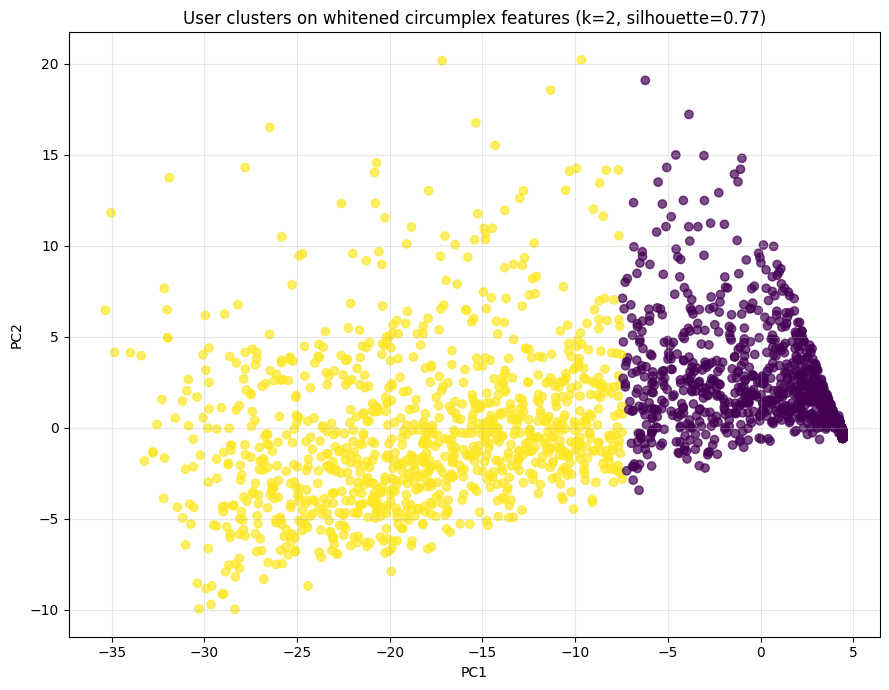

,mean_val_w,mean_aro_w,std_val_w,std_aro_w,mean_rad_w,std_rad_w,mu_x,mu_y,R_w
cluster,,,,,,,,,
0,-0.254,0.126,0.059,0.063,1.104,0.059,-0.328,0.175,0.985
1,0.025,0.003,0.798,0.830,1.225,0.601,-0.086,0.051,0.404


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

uw = np.hypot(weekly_vad['valence_w'], weekly_vad['arousal_w'])
ux = (weekly_vad['valence_w'] / uw).fillna(0.0)
uy = (weekly_vad['arousal_w'] / uw).fillna(0.0)

weekly_vad = weekly_vad.assign(mu_x=ux, mu_y=uy)

user_vad = (
    weekly_vad.groupby('user_id')
    .agg(
        mean_val_w = ('valence_w','mean'),
        mean_aro_w = ('arousal_w','mean'),
        std_val_w  = ('valence_w','std'),
        std_aro_w  = ('arousal_w','std'),
        mean_rad_w = ('radius_w','mean'),
        std_rad_w  = ('radius_w','std'),
        mu_x       = ('mu_x','mean'),  
        mu_y       = ('mu_y','mean'),  
        n_weeks    = ('week','nunique')
    )
    .fillna(0.0)
)

user_vad['R_w'] = np.hypot(user_vad['mu_x'], user_vad['mu_y'])

feat_cols = ['mean_val_w','mean_aro_w','std_val_w','std_aro_w','mean_rad_w','std_rad_w','mu_x','mu_y','R_w']
X = RobustScaler().fit_transform(user_vad[feat_cols].values)

# small sweep for best k
cands = range(2,5)
best_k, best_s = max(((k, silhouette_score(X, KMeans(k, random_state=42).fit_predict(X)))
                      for k in cands), key=lambda t: t[1])

labels = KMeans(best_k, random_state=42).fit_predict(X)

# 2D view 
Z = PCA(2, random_state=42).fit_transform(X)
plt.figure(figsize=(9,7))
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap='viridis', alpha=.7)
plt.title(f'User clusters on whitened circumplex features (k={best_k}, silhouette={best_s:.2f})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

# Cluster means to interpret segments
cluster_summary = (
    pd.DataFrame(user_vad[feat_cols].values, index=user_vad.index, columns=feat_cols)
      .assign(cluster=labels)
      .groupby('cluster').mean().round(3)
)
cluster_summary


Cluster 0: more negative set-point (mean_val_w −0.25), slightly activated (mean_aro_w 0.13), very consistent direction (R_w 0.99) and low variability (std_val/aro ≈ 0.06).

Cluster 1: near-neutral set-point (val ~0.03, aro ~0.00), diffuse/variable affect (std_val/aro ≈ 0.80, R_w 0.40) and a bit higher average intensity (mean_rad_w 1.23).

Users split into a stable, negatively-valenced group vs. a more variable, near-neutral group; separation is clean (silhouette 0.77).

In [38]:
print(user_vad.describe().round(3))

       mean_val_w  mean_aro_w  std_val_w  std_aro_w  mean_rad_w  std_rad_w  \
count    6318.000    6318.000   6318.000   6318.000    6318.000   6318.000   
mean       -0.208       0.106      0.182      0.190       1.124      0.149   
std         0.726       0.788      0.393      0.396       0.625      0.313   
min        -2.977      -3.299      0.000      0.000       0.005      0.000   
25%        -0.631      -0.295      0.000      0.000       0.705      0.000   
50%        -0.282       0.180      0.000      0.000       0.995      0.000   
75%         0.110       0.591      0.152      0.177       1.389      0.128   
max         5.015       3.104      3.774      3.357       5.245      2.549   

           mu_x      mu_y   n_weeks       R_w  
count  6318.000  6318.000  6318.000  6318.000  
mean     -0.288     0.155     2.606     0.889  
std       0.573     0.640    10.947     0.233  
min      -1.000    -1.000     1.000     0.001  
25%      -0.779    -0.360     1.000     0.972  
50%      

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_30810/1688829743.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wk = g.apply(


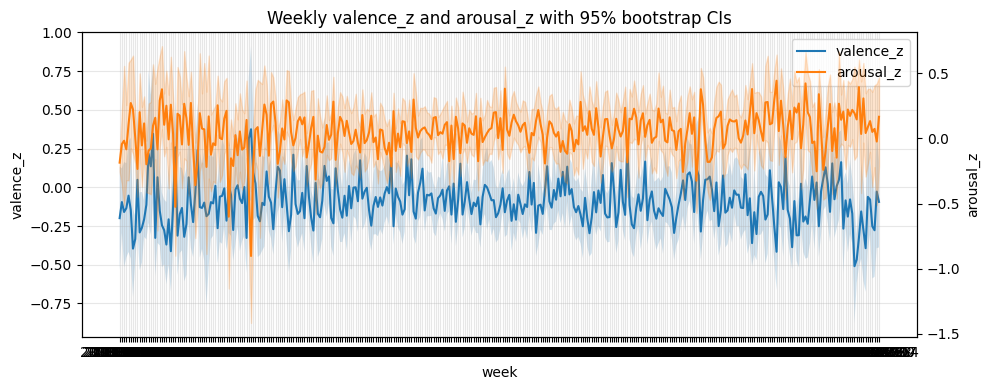

In [ ]:
# bootstrap CI function
rng = np.random.default_rng(42)

def ci_boot_mean(x, B=400):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n == 0:
        return (np.nan, np.nan)
    # (B, n) bootstrap resamples then mean over axis=1
    boot_means = rng.choice(x, size=(B, n), replace=True).mean(axis=1)
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return lo, hi

g = weekly_vad.groupby('week', sort=True)

wk = g.apply(
    lambda df: pd.Series({
        'val_m': df['valence_z'].mean(),
        'val_lo': ci_boot_mean(df['valence_z'])[0],
        'val_hi': ci_boot_mean(df['valence_z'])[1],
        'aro_m': df['arousal_z'].mean(),
        'aro_lo': ci_boot_mean(df['arousal_z'])[0],
        'aro_hi': ci_boot_mean(df['arousal_z'])[1],
        'n_users': df['user_id'].nunique()
    })
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wk['week'], wk['val_m'], label='valence_z')
ax.fill_between(wk['week'], wk['val_lo'], wk['val_hi'], alpha=0.2)

ax2 = ax.twinx()
ax2.plot(wk['week'], wk['aro_m'], color='tab:orange', label='arousal_z')
ax2.fill_between(wk['week'], wk['aro_lo'], wk['aro_hi'], color='tab:orange', alpha=0.2)

ax.grid(True, alpha=.3)
ax.set_title('Weekly valence_z and arousal_z with 95% bootstrap CIs')
ax.set_xlabel('week')
ax.set_ylabel('valence_z')
ax2.set_ylabel('arousal_z')

# simple combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines+lines2, labels+labels2, loc='upper right')
plt.tight_layout()
plt.show()


Weekly z-scored affect shows persistently elevated arousal and mildly negative valence relative to the corpus baseline; bootstrap 95% CIs are narrow, indicating stable estimates, with short-lived excursions rather than regime shifts.

Text(0, 0.5, 'share')

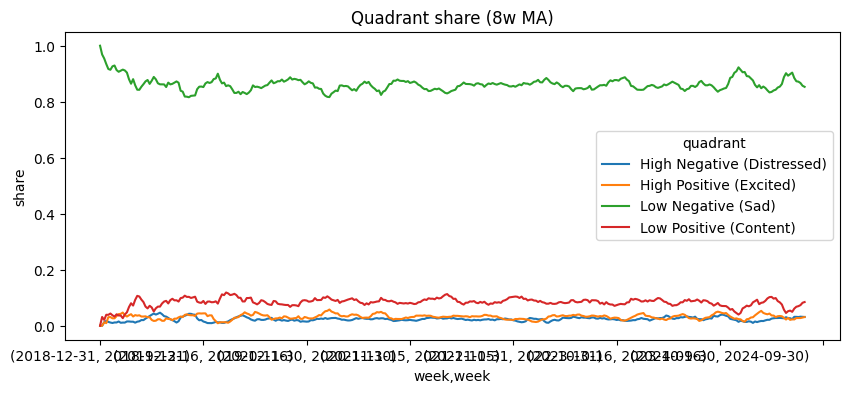

In [40]:
q_week = mapped.groupby(['week','quadrant']).size().groupby(level=0).apply(lambda s: s/s.sum()).unstack().fillna(0)
q_week.rolling(8, min_periods=1).mean().plot(figsize=(10,4), title='Quadrant share (8w MA)'); plt.ylabel('share')


<Axes: title={'center': 'Weekly valence & arousal (1w MA)'}, xlabel='week'>

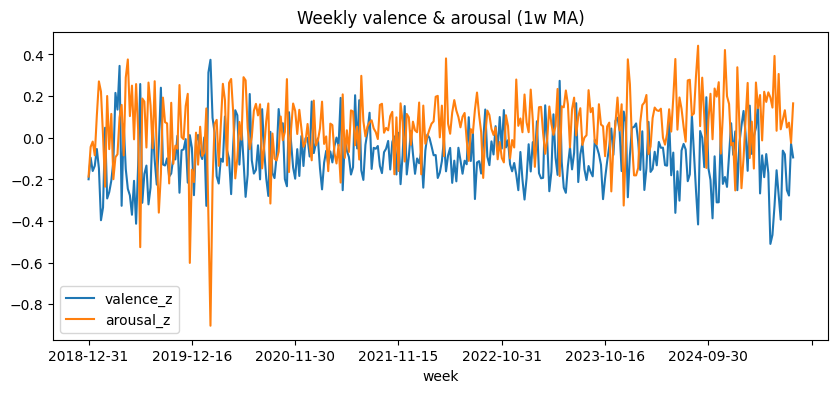

In [41]:
va_week = weekly_vad.groupby('week')[['valence_z','arousal_z']].mean()
va_week.rolling(1, min_periods=1).mean().plot(figsize=(10,4), title='Weekly valence & arousal (1w MA)')


<Axes: title={'center': 'Weekly valence & arousal (4w MA)'}, xlabel='week'>

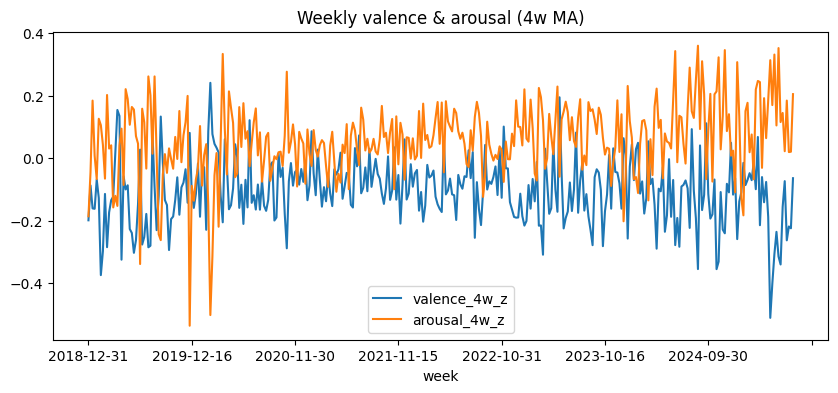

In [42]:
va_4week = weekly_vad.groupby('week')[['valence_4w_z','arousal_4w_z']].mean()
va_4week.rolling(1, min_periods=1).mean().plot(figsize=(10,4), title='Weekly valence & arousal (4w MA)')


<Axes: title={'center': 'Weekly valence & arousal (8w MA)'}, xlabel='week'>

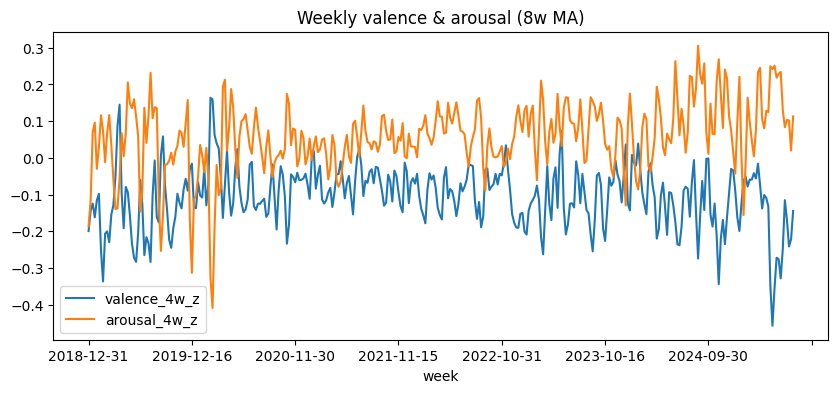

In [43]:
va_8week = weekly_vad.groupby('week')[['valence_4w_z','arousal_4w_z']].mean()
va_8week.rolling(2, min_periods=1).mean().plot(figsize=(10,4), title='Weekly valence & arousal (8w MA)')


In [44]:
mapped.to_csv("./data/circumplex_post_level.csv", index=False)

In [45]:
wk = (mapped
      .groupby('week', sort=True)
      .agg(valence_z_mean=('valence_z','mean'),
           arousal_z_mean=('arousal_z','mean'),
           radius_z_mean =('radius_z','mean'),
           n_posts=('user_id','size'),
           n_users=('user_id','nunique'))
      .reset_index())
wk.to_csv('./data/circumplex_weekly.csv', index=False)

In [46]:
em_cols = [c for c in mapped.columns if c.startswith("empath_")]

wk_user = (mapped
           .groupby(['user_id','week'], sort=True)
           .agg(**{f'{em}_mean': (em, 'mean') for em in em_cols},
                valence_z_mean=('valence_z','mean'),
                arousal_z_mean=('arousal_z','mean'),
                radius_z_mean=('radius_z','mean'),
                n_posts=('post_id','size'))
           .reset_index())
wk_user.to_csv('./data/circumplex_weekly_user.csv', index=False)

In [ ]:
def user_vad_features(df):
    uv = (df.groupby('user_id')
          .agg(mean_val_w=('valence_w','mean'),
               mean_aro_w=('arousal_w','mean'),
               std_val_w =('valence_w','std'),
               std_aro_w =('arousal_w','std'),
               mean_rad_w=('radius_w','mean'),
               std_rad_w =('radius_w','std'),
               n_weeks   =('week','nunique'))
          .fillna(0.0))
    # circular concentration
    theta = np.arctan2(df['arousal_w'], df['valence_w'])
    uv['mu_x'] = df.groupby('user_id').apply(lambda d: np.cos(np.arctan2(d['arousal_w'], d['valence_w'])).mean()).values
    uv['mu_y'] = df.groupby('user_id').apply(lambda d: np.sin(np.arctan2(d['arousal_w'], d['valence_w'])).mean()).values
    uv['R_w']  = np.hypot(uv['mu_x'], uv['mu_y'])
    return uv.reset_index()

user_agg = user_vad_features(mapped)
user_agg.to_csv('./data/circumplex_users.csv', index=False)

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_30810/3983585402.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  uv['mu_x'] = df.groupby('user_id').apply(lambda d: np.cos(np.arctan2(d['arousal_w'], d['valence_w'])).mean()).values
/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_30810/3983585402.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  uv['mu_y'] = df.groupby('user_id').apply(lamb

In [48]:
keep_empath = [c for c in mapped.columns if c.startswith('empath_')]
mu_v, sd_v = mapped['valence'].mean(), mapped['valence'].std(ddof=0)
mu_a, sd_a = mapped['arousal'].mean(), mapped['arousal'].std(ddof=0)
Z = mapped[['valence_z','arousal_z']].to_numpy()
Sigma = np.cov(Z, rowvar=False)
w, V = np.linalg.eigh(Sigma)
W = V @ np.diag(1/np.sqrt(w+1e-12)) @ V.T  # 2x2 whitener

params_rows = [
    ['nrc_version','2.1'],
    ['vad_scale','[-1,1]'],
    ['thr','0.03'],
    ['min_posts','100'],
    ['z_mean_valence', f'{mu_v:.6f}'],
    ['z_std_valence',  f'{sd_v:.6f}'],
    ['z_mean_arousal', f'{mu_a:.6f}'],
    ['z_std_arousal',  f'{sd_a:.6f}'],
    ['cov_z_00', f'{Sigma[0,0]:.6f}'], ['cov_z_01', f'{Sigma[0,1]:.6f}'],
    ['cov_z_10', f'{Sigma[1,0]:.6f}'], ['cov_z_11', f'{Sigma[1,1]:.6f}'],
    ['W_00', f'{W[0,0]:.8f}'], ['W_01', f'{W[0,1]:.8f}'],
    ['W_10', f'{W[1,0]:.8f}'], ['W_11', f'{W[1,1]:.8f}'],
]
pd.DataFrame(params_rows, columns=['key','value']).to_csv('./data/circumplex_params.csv', index=False)
pd.Series([c for c in keep_empath]).to_csv('./data/circumplex_vad_cols.csv', index=False, header=False)

In [49]:
! python symptoms_from_va.py

Saved → ./data/outputs/symptoms_weekly_user.csv (Empath _z kept: True)


In [50]:
sym = pd.read_csv("./data/outputs/symptoms_weekly_user.csv")
sym.head()

,user_id,week,valence_w,arousal_w,radius_w,n_posts,anx_score,dep_score,ptsd_score,mania_score,...,empath_health_mean_z,empath_contentment_mean_z,empath_fear_mean_z,empath_trust_mean_z,empath_hate_mean_z,empath_therapy_mean_z,empath_sleep_mean_z,empath_anger_mean_z,empath_shame_mean_z,empath_optimism_mean_z
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,0.707331,0.527432,2.035154,-0.767102,0.685984,1.151567,0.087742,-0.441444,0.324786,0.612550
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,-0.856687,-0.727392,-0.731852,3.171496,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,-0.064543,0.244382,-0.510700,0.205964,-0.679259,0.131225,-0.417312,-0.441444,-0.027287,0.502107
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,-0.295585,0.730268,0.834639,-0.767102,1.084869,-0.706984,-0.417312,-0.441444,2.268624,0.575207
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,-0.423351,0.166135,-0.284283,-0.130561,-0.511247,-0.230628,-0.417312,-0.178049,0.553874,0.352986


In [51]:
# prevalence per label
labels = ["anx_label","dep_label","ptsd_label","mania_label","sui_label"]
prev = sym[labels].mean().sort_values(ascending=False)
print("Label prevalence:\n", (prev*100).round(1), "%")

# correlations with VA
scores = ["anx_score","dep_score","ptsd_score","mania_score","sui_score"]
va_corr = sym[["valence_w","arousal_w"] + scores].corr().loc[["valence_w","arousal_w"], scores]
print("\nCorr( VA , scores )\n", va_corr.round(3))

# dampen very sparse weeks
mask = sym["n_posts"] < 2
sym.loc[mask, [s for s in scores]] *= (sym.loc[mask, "n_posts"]/2).clip(0,1)

# EMA smoothing per user and label
sym = sym.sort_values(["user_id","week"])
for s in scores:
    sym[s] = sym.groupby("user_id")[s].apply(lambda x: x.ewm(alpha=0.3, adjust=False).mean()).values

Label prevalence:
 ptsd_label     19.4
anx_label      16.9
sui_label      10.3
dep_label       5.4
mania_label     3.0
dtype: float64 %

Corr( VA , scores )
            anx_score  dep_score  ptsd_score  mania_score  sui_score
valence_w     -0.329     -0.332      -0.399        0.212     -0.455
arousal_w      0.429     -0.043       0.416        0.110      0.087
